In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import os
import matplotlib.pyplot as plt
import openml
import yaml
import tqdm
from pymoo.indicators.hv import HV
import warnings
from multiprocessing import Pool
from joblib import Parallel, delayed
from utility import compute_min_max, get_pareto_front, compute_ranks, compute_extremes, get_all_dataframes, get_group_task_ids

#plt.rcParams['lines.linewidth'] = 3

pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

FONT_SIZE = 12

keys = ["random", "so-smac", "mo-smac", "so-asha", "mo-asha", "nsga2"]

cmap = plt.get_cmap("Set1")   # ColorBrewer Set1 (9 colors)

COLORS = {key: cmap(i) for i, key in enumerate(keys)}

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.weight": "normal",
    "font.size": FONT_SIZE,
    "axes.labelsize": FONT_SIZE,      # axis labels
    "axes.titlesize": FONT_SIZE,      # subplot titles
    "xtick.labelsize": FONT_SIZE,     # x tick labels
    "ytick.labelsize": FONT_SIZE,     # y tick labels
    "legend.fontsize": FONT_SIZE,     # legend
    "figure.titlesize": FONT_SIZE + 4     # suptitle
})

In [2]:
data_meta = pd.read_csv("./data/base_ensemble_pools_meta.csv")
data = pd.read_csv("./data/base_ensemble_pools.csv", index_col=0)

data_bm = pd.read_csv("./data/base_model_pools.csv", index_col=0)
data_bm_meta = pd.read_csv("./data/base_model_pools_meta.csv")

In [3]:
print(data.head())
print(data_meta.head())
print(data_bm.head())
print(data_bm_meta.head())

                 RMSE  inference_time  energy_consumption  ensemble_size  avg_gap  task_id  seed bmg_method  pool_index frequency      es_method filter  Log Loss  1 - ROC AUC
Unnamed: 0                                                                                                                                                                    
0           25.637487        0.227711            0.540527            4.0      0.0   167210     1     random           0  no-boost  energy-qdo-es  nd_50       NaN          NaN
1           30.312872        0.078179            0.114014            2.0      0.0   167210     1     random           0  no-boost  energy-qdo-es  nd_50       NaN          NaN
2           21.995853        0.239232            0.555588            4.0      0.0   167210     1     random           0  no-boost  energy-qdo-es  nd_50       NaN          NaN
3           22.808596        0.233642            0.549224            4.0      0.0   167210     1     random           0  no-b

# Plots:

1. Vergleich der verschiedenen Pruning Methoden
    - Matrix Plot: Ensembling Methods X Pruning Methods: Hypervolume compared to best solution

2. Vergleich der Laufzeiten der Ensembling Methoden
    - Boxplot

In [5]:
BMG_METHODS_DICT = {
    "random" : "Random Search",
    "nsga2" : "NSGA-II",
    "so-smac" : "SO-SMAC",
    "mo-smac" : "MO-SMAC",
    "so-asha" : "SO-ASHA",
    "mo-asha" : "MO-ASHA",
}
BMG_METHODS = list(BMG_METHODS_DICT.keys())

ENSEMBLING_METHODS_DICT = {
    "ges" : "GES",
    "qdo-es" : "QDO-ES",
    "infer-qdo-es" : "Infer-QDO-ES",
    "size-qdo-es" : "Size-QDO-ES",
    "energy-qdo-es" : "Energy-QDO-ES",
    "mo-ges" : "MO-GES",
}
ENSEMBLING_METHODS = list(ENSEMBLING_METHODS_DICT.keys())

PRUNING_METHODS_DICT = {
    "top_50" : "Top 50",
    "silo_top_50" : "Silo Top 50",
    "nd_50" : "NDS Top 50",
    "nd_50_silo" : "Silo NDS Top 50",
    "nd_first_pareto" : "Pareto Rank =1",
    "nd_second_pareto" : "Pareto Rank ≤2",
    "nd_third_pareto" : "Pareto Rank ≤3",
}
PRUNING_METHODS = list(PRUNING_METHODS_DICT.keys())
PRUNING_METHODS_SMALL = ["none", "nd_first_pareto", "nd_second_pareto", "nd_third_pareto"]

In [6]:
all_df = get_all_dataframes()
min_max_values = compute_min_max(all_df)
assert len(min_max_values) == 104
print("Min/max computation successful.")

/home/janek/Dokumente/master_thesis/Python/utility.py:110: UserWarning: Also add ensemble pools with multi-threading and frequency scaling etc. here!
  warnings.warn("Also add ensemble pools with multi-threading and frequency scaling etc. here!")


Min/max computation successful.


In [7]:
extremes = compute_extremes(min_max_values, all_df)
assert len(extremes) == 104
print("Extremes computation successful.")

Extremes computation successful.


# Compute all metrics for all base model and ensemble pools

In [ ]:
data_bm_grouped = data_bm.groupby(["task_id", "seed", "bmg_method", "frequency"])
data_grouped = data.groupby(["task_id", "seed", "bmg_method", "frequency"])

for (task_id, seed, bmg_method, frequency), group in data_bm_grouped:
    

In [76]:
bmps = {}
bmp_hvs = np.zeros((104, 5, 6, 2)) + np.nan

task_ids = sorted(list(data_bm["task_id"].unique()))
assert len(task_ids) == 104
seeds = sorted(list(data_bm["seed"].unique()))
assert len(seeds) == 5
bmg_methods = sorted(list(data_bm["bmg_method"].unique()))
assert len(bmg_methods) == 6
frequencies = sorted(list(data_bm["frequency"].unique()))
assert len(frequencies) == 2

task_id_to_idx = {v: i for i, v in enumerate(task_ids)}
seed_to_idx = {v: i for i, v in enumerate(seeds)}
bmg_to_idx = {v: i for i, v in enumerate(bmg_methods)}
freq_to_idx = {v: i for i, v in enumerate(frequencies)}

grouped = data_bm.groupby("pool_index", sort=False)

for g_index, g_data in tqdm.tqdm(grouped, total=grouped.ngroups):
    task_id = g_data["task_id"].iloc[0]
    seed = g_data["seed"].iloc[0]
    bmg_method = g_data["bmg_method"].iloc[0]
    frequency = g_data["frequency"].iloc[0]

    cols = ["RMSE", "Log Loss", "1 - ROC AUC", "inference_time", "energy_consumption"]
    cols = [col for col in cols if (~g_data[col].isna()).sum() > 0]

    min_val, max_val = min_max_values[task_id]
    min_arr, max_arr = np.array([min_val[col] for col in cols]), np.array([max_val[col] for col in cols])

    data_norm = g_data[cols].values
    data_norm = (data_norm - min_arr) / (max_arr - min_arr)

    hv = HV(ref_point=[1] * len(cols))
    hv_value = hv(data_norm)
    bmp_hvs[task_id_to_idx[task_id], seed_to_idx[seed], bmg_to_idx[bmg_method], freq_to_idx[frequency]] = hv_value

    bmps[(task_id, seed, bmg_method, frequency)] = data_norm

  0%|          | 0/6228 [00:00<?, ?it/s]

100%|██████████| 6228/6228 [00:07<00:00, 817.49it/s] 


In [ ]:
def min_distance(vectors, paret_front):
    diff = vectors[:, None, :] - paret_front[None, :, :]
    dist = np.linalg.norm(diff, axis=2)
    same = np.all(np.isclose(vectors[:, None, :], paret_front[None, :, :]), axis=2)
    dist[same] = np.inf
    return np.min(dist, axis=1)

def compute_spread(extent, sum_deviations, denom):
    if not np.isfinite(sum_deviations) or not np.isfinite(extent):
        return np.inf
    return (extent + sum_deviations) / (extent + denom)

def compute_extent(pareto_front, cols, extremes):
    extremes_array = np.array([[e[col] for col in cols] for e in extremes.values()])
    sum_extremes = np.sum(min_distance(extremes_array, pareto_front))
    return sum_extremes

def compute_uniformity_components(pareto_front, cols, extremes):
    distances = min_distance(pareto_front, pareto_front)

    if np.any(np.isinf(distances)) or len(pareto_front) <= len(cols):
        return np.inf, 1
        
    d_mean = np.mean(distances)
    sum_deviations = np.sum(np.abs(distances - d_mean))
    return sum_deviations, (len(pareto_front) - len(cols)) * d_mean

def compute_uniformity(sum_deviations, denom):
    return sum_deviations / denom

In [10]:
from multiprocessing import Pool
from joblib import Parallel, delayed

task_ids = sorted(list(data["task_id"].unique()))
assert len(task_ids) == 104
seeds = sorted(list(data["seed"].unique()))
assert len(seeds) == 5
bmg_methods = sorted(list(data["bmg_method"].unique()))
assert len(bmg_methods) == 6
frequencies = sorted(list(data["frequency"].unique()))
assert len(frequencies) == 2
ensembling_methods = sorted(list(data["es_method"].unique()))
assert len(ensembling_methods) == 6
pruning_methods = sorted(list(data["filter"].unique()))
assert len(pruning_methods) == 8

task_id_to_idx = {v: i for i, v in enumerate(task_ids)}
seed_to_idx = {v: i for i, v in enumerate(seeds)}
bmg_to_idx = {v: i for i, v in enumerate(bmg_methods)}
freq_to_idx = {v: i for i, v in enumerate(frequencies)}
es_to_idx = {v: i for i, v in enumerate(ensembling_methods)}

pred_metrics_per_task = {}

pruning_methods = [p for p in pruning_methods if p != "none"]
prune_to_idx = {v: i for i, v in enumerate(pruning_methods)}
prune_to_idx.update({"none": [pruning_methods.index("top_50"), pruning_methods.index("silo_top_50"), pruning_methods.index("nd_50"), pruning_methods.index("nd_50_silo")]})

grouped = data.groupby("pool_index", sort=False)

def process_pool(pool_index, pool_data):
    if pool_data.empty:
        return None

    # Extract metadata efficiently
    row = pool_data.iloc[0]
    task_id = row["task_id"]
    seed = row["seed"]
    bmg_method = row["bmg_method"]
    ensembling_method = row["es_method"]
    pruning_method = row["filter"]
    frequency = row["frequency"]

    cols = ["RMSE", "Log Loss", "1 - ROC AUC", "inference_time", "energy_consumption"]
    cols = [col for col in cols if (~pool_data[col].isna()).sum() > 0]
    pred_metrics_per_task[task_id] = cols[0]

    # Compute hypervolume
    min_val, max_val = min_max_values[task_id]
    extreme_sols = extremes[task_id]
    min_arr, max_arr = np.array([min_val[col] for col in cols]), np.array([max_val[col] for col in cols])

    data_norm = pool_data[cols].values
    data_norm = (data_norm - min_arr) / (max_arr - min_arr)

    data_bmp = bmps[(task_id, seed, bmg_method, frequency)] # already normalized
    data_norm_incl_bmp = np.vstack([data_norm, data_bmp])

    ind = HV(ref_point=[1] * len(cols))
    hv = ind(data_norm)
    hv_incl_bmp = ind(data_norm_incl_bmp)
    rel_hv_improvement = hv_incl_bmp / bmp_hvs[task_id_to_idx[task_id], seed_to_idx[seed], bmg_to_idx[bmg_method], freq_to_idx[frequency]]
    
    pareto_ensembling = get_pareto_front(data_norm)
    pareto_full = get_pareto_front(data_norm_incl_bmp)
    pareto_bmp = get_pareto_front(data_bmp)
    n_pareto_ensembling = np.sum(pareto_ensembling)
    n_pareto_full = np.sum(pareto_full)
    n_pareto_bmp = np.sum(pareto_bmp)


    uniformity_ensembling_sum_dev, uniformity_ensembling_denom = compute_uniformity_components(data_norm[pareto_ensembling], cols, extreme_sols)
    uniformity_full_sum_dev, uniformity_full_denom = compute_uniformity_components(data_norm_incl_bmp[pareto_full], cols, extreme_sols)
    uniformity_bmp_sum_dev, uniformity_bmp_denom = compute_uniformity_components(data_bmp[pareto_bmp], cols, extreme_sols)

    uniformity_ensembling = compute_uniformity(uniformity_ensembling_sum_dev, uniformity_ensembling_denom)
    uniformity_full = compute_uniformity(uniformity_full_sum_dev, uniformity_full_denom)
    uniformity_bmp = compute_uniformity(uniformity_bmp_sum_dev, uniformity_bmp_denom)

    extent_ensembling = compute_extent(data_norm[pareto_ensembling], cols, extreme_sols)
    extent_full = compute_extent(data_norm_incl_bmp[pareto_full], cols, extreme_sols)
    extent_bmp = compute_extent(data_bmp[pareto_bmp], cols, extreme_sols)

    spread_ensembling = compute_spread(extent_ensembling, uniformity_ensembling_sum_dev, uniformity_ensembling_denom)
    spread_full = compute_spread(extent_full, uniformity_full_sum_dev, uniformity_full_denom)
    spread_bmp = compute_spread(extent_bmp, uniformity_bmp_sum_dev, uniformity_bmp_denom)

    meta = data_meta[data_meta["pool_index"] == pool_index].iloc[0]
    runtime = meta["runtime"]
    n_models = meta["n_models"]
    pred_time_sum = meta["sum_pred_time"]
    pred_energy_sum = meta["sum_pred_energy"]

    best_single_bmp, best_single_ensembling = [], []
    for i, col in enumerate(cols):
        best_single_bmp.append(data_bmp[:, i].min())
        best_single_ensembling.append(data_norm[:, i].min())

    metrics = [
        hv, hv_incl_bmp, rel_hv_improvement, n_pareto_ensembling,
        n_pareto_full, n_pareto_bmp, spread_ensembling, spread_full, 
        spread_bmp, extent_ensembling, extent_full, extent_bmp,
        uniformity_ensembling, uniformity_full, uniformity_bmp,
        runtime, n_models, pred_time_sum, pred_energy_sum,
        *best_single_bmp, *best_single_ensembling
    ]

    metrics = [np.nan if not np.isfinite(m) else m for m in metrics]

    return (task_id, seed, bmg_method, ensembling_method, pruning_method, frequency, metrics)


def _worker(item):
    pool_index, pool_data = item
    return process_pool(pool_index, pool_data)

with Pool() as p:
     results = []
     for r in tqdm.tqdm(p.imap_unordered(_worker, grouped), total=grouped.ngroups):
         results.append(r)

100%|██████████| 177672/177672 [01:46<00:00, 1661.71it/s]


In [84]:
RESULTS_ORDER = [
    "Hypervolume", "Hypervolume incl. BMP", "Relative Hypervolume Improvement", "Size of Pareto Front",
    "Size of Pareto Front incl. BMP", "Size of Pareto Front BMP", "Spread", "Spread incl. BMP", "Spread BMP", 
    "Extent Ensembling", "Extent Full", "Extent BMP", "Uniformity Ensembling", "Uniformity Full", "Uniformity BMP", "Runtime Ensembling",
    "Number of Models", "Sum of Prediction Times", "Sum of Prediction Energies", "Predictive Metric BMP", "Inference Time BMP",
    "Energy Consumption BMP", "Predictive Metric Ensembling", "Inference Time Ensembling", "Energy Consumption Ensembling"
]

results_arr = np.zeros((2, 104, len(BMG_METHODS), 5, len(ENSEMBLING_METHODS), len(PRUNING_METHODS), len(RESULTS_ORDER))) + np.nan

for res in results:
    if res is None:
        continue
    
    task_id, seed, bmg_method, ensembling_method, pruning_method, frequency, res_ = res

    i_task = task_id_to_idx[task_id]
    i_seed = seed_to_idx[seed]
    i_bmg = bmg_to_idx[bmg_method]
    i_freq = freq_to_idx[frequency]
    i_es = es_to_idx[ensembling_method]
    idx_prun = prune_to_idx[pruning_method]

    if isinstance(idx_prun, list):
        for i_prun in idx_prun:
            results_arr[i_freq, i_task, i_bmg, i_seed, i_es, i_prun] = res_
    else:
        results_arr[i_freq, i_task, i_bmg, i_seed, i_es, idx_prun] = res_

In [ ]:
def reverse_search(dict, value):
    for k, v in dict.items():
        if v == value:
            return k
    return None

In [88]:
is_nan_entries = np.isnan(results_arr[..., ])
for i in range(len(np.where(is_nan_entries)[0])):
    index_tuple = tuple(idx[i] for idx in np.where(is_nan_entries))

    task_id = reverse_search(task_id_to_idx, index_tuple[1])
    bmg_method = reverse_search(bmg_to_idx, index_tuple[2])
    ensembling_method = reverse_search(es_to_idx, index_tuple[4])
    pruning_method = reverse_search(prune_to_idx, index_tuple[5])
    frequency = reverse_search(freq_to_idx, index_tuple[0])
    seed = reverse_search(seed_to_idx, index_tuple[3])
    metric = RESULTS_ORDER[index_tuple[6]]

    print(f"NaN entry at Task ID {task_id}, BMG Method {bmg_method}, Ensembling Method {ensembling_method}, Pruning Method {pruning_method}, Frequency {frequency}, Seed {seed}, Metric {metric}")


NaN entry at Task ID 2073, BMG Method mo-asha, Ensembling Method energy-qdo-es, Pruning Method nd_first_pareto, Frequency boost, Seed 1, Metric Spread
NaN entry at Task ID 2073, BMG Method mo-asha, Ensembling Method energy-qdo-es, Pruning Method nd_first_pareto, Frequency boost, Seed 1, Metric Uniformity Ensembling
NaN entry at Task ID 2073, BMG Method mo-asha, Ensembling Method energy-qdo-es, Pruning Method nd_second_pareto, Frequency boost, Seed 1, Metric Spread
NaN entry at Task ID 2073, BMG Method mo-asha, Ensembling Method energy-qdo-es, Pruning Method nd_second_pareto, Frequency boost, Seed 1, Metric Uniformity Ensembling
NaN entry at Task ID 2073, BMG Method mo-asha, Ensembling Method energy-qdo-es, Pruning Method nd_third_pareto, Frequency boost, Seed 1, Metric Spread
NaN entry at Task ID 2073, BMG Method mo-asha, Ensembling Method energy-qdo-es, Pruning Method nd_third_pareto, Frequency boost, Seed 1, Metric Uniformity Ensembling
NaN entry at Task ID 2073, BMG Method mo-asha, 

KeyboardInterrupt: 

In [87]:
for metric in RESULTS_ORDER:
    metric_idx = RESULTS_ORDER.index(metric)
    print("Metric:", metric)
    print(np.sum(np.isnan(results_arr[..., metric_idx])), "of", np.prod(results_arr[..., metric_idx].shape), "values are NaN.")
    print(np.sum(np.isnan(results_arr[..., metric_idx])) / results_arr[..., metric_idx].size * 100, "% of values are NaN.")

Metric: Hypervolume
2760 of 262080 values are NaN.
1.0531135531135531 % of values are NaN.
Metric: Hypervolume incl. BMP
2760 of 262080 values are NaN.
1.0531135531135531 % of values are NaN.
Metric: Relative Hypervolume Improvement
2760 of 262080 values are NaN.
1.0531135531135531 % of values are NaN.
Metric: Size of Pareto Front
2760 of 262080 values are NaN.
1.0531135531135531 % of values are NaN.
Metric: Size of Pareto Front incl. BMP
2760 of 262080 values are NaN.
1.0531135531135531 % of values are NaN.
Metric: Size of Pareto Front BMP
2760 of 262080 values are NaN.
1.0531135531135531 % of values are NaN.
Metric: Spread
136402 of 262080 values are NaN.
52.04594017094018 % of values are NaN.
Metric: Spread incl. BMP
32075 of 262080 values are NaN.
12.238629426129426 % of values are NaN.
Metric: Spread BMP
69834 of 262080 values are NaN.
26.64606227106227 % of values are NaN.
Metric: Extent Ensembling
2796 of 262080 values are NaN.
1.0668498168498168 % of values are NaN.
Metric: Ext

In [12]:
# Impute max spread for empty ensembles or ensembles with single model etc.
max_spread = np.nanmax(np.take(results_arr, RESULTS_ORDER.index("Spread"), axis=-1), axis=(2,3,4,5))
max_spread_incl_bmp = np.nanmax(np.take(results_arr, RESULTS_ORDER.index("Spread incl. BMP"), axis=-1), axis=(2,3,4,5))

for i_task in range(len(task_ids)):
    for i_freq in range(len(frequencies)):
        mask_spread = np.isnan(results_arr[i_freq, i_task, :, :, :, :, RESULTS_ORDER.index("Spread")])
        results_arr[i_freq, i_task, :, :, :, :, RESULTS_ORDER.index("Spread")][mask_spread] = max_spread[i_freq, i_task]
        mask_spread_incl_bmp = np.isnan(results_arr[i_freq, i_task, :, :, :, :, RESULTS_ORDER.index("Spread incl. BMP")])
        results_arr[i_freq, i_task, :, :, :, :, RESULTS_ORDER.index("Spread incl. BMP")][mask_spread_incl_bmp] = max_spread_incl_bmp[i_freq, i_task]

        mask_hv = np.isnan(results_arr[i_freq, i_task, :, :, :, :, RESULTS_ORDER.index("Hypervolume")])
        results_arr[i_freq, i_task, :, :, :, :, RESULTS_ORDER.index("Hypervolume")][mask_hv] = 0.0
        mask_hv_incl_bmp = np.isnan(results_arr[i_freq, i_task, :, :, :, :, RESULTS_ORDER.index("Hypervolume incl. BMP")])
        results_arr[i_freq, i_task, :, :, :, :, RESULTS_ORDER.index("Hypervolume incl. BMP")][mask_hv_incl_bmp] = 0.0
        mask_rel_hv = np.isnan(results_arr[i_freq, i_task, :, :, :, :, RESULTS_ORDER.index("Relative Hypervolume Improvement")])
        results_arr[i_freq, i_task, :, :, :, :, RESULTS_ORDER.index("Relative Hypervolume Improvement")][mask_rel_hv] = 0.0

        mask_pareto_size = np.isnan(results_arr[i_freq, i_task, :, :, :, :, RESULTS_ORDER.index("Size of Pareto Front")])
        results_arr[i_freq, i_task, :, :, :, :, RESULTS_ORDER.index("Size of Pareto Front")][mask_pareto_size] = 0.0
        mask_pareto_size_bmp = np.isnan(results_arr[i_freq, i_task, :, :, :, :, RESULTS_ORDER.index("Size of Pareto Front incl. BMP")])
        results_arr[i_freq, i_task, :, :, :, :, RESULTS_ORDER.index("Size of Pareto Front incl. BMP")][mask_pareto_size_bmp] = 0.0

        mask_n_models = np.isnan(results_arr[i_freq, i_task, :, :, :, :, RESULTS_ORDER.index("Number of Models")])
        results_arr[i_freq, i_task, :, :, :, :, RESULTS_ORDER.index("Number of Models")][mask_n_models] = 0.0
        mask_runtime = np.isnan(results_arr[i_freq, i_task, :, :, :, :, RESULTS_ORDER.index("Runtime Ensembling")])
        results_arr[i_freq, i_task, :, :, :, :, RESULTS_ORDER.index("Runtime Ensembling")][mask_runtime] = 0.0
        mask_pred_time = np.isnan(results_arr[i_freq, i_task, :, :, :, :, RESULTS_ORDER.index("Sum of Prediction Times")])
        results_arr[i_freq, i_task, :, :, :, :, RESULTS_ORDER.index("Sum of Prediction Times")][mask_pred_time] = 0.0
        mask_pred_energy = np.isnan(results_arr[i_freq, i_task, :, :, :, :, RESULTS_ORDER.index("Sum of Prediction Energies")])
        results_arr[i_freq, i_task, :, :, :, :, RESULTS_ORDER.index("Sum of Prediction Energies")][mask_pred_energy] = 0.0

        mask_pred_metric_bmp = np.isnan(results_arr[i_freq, i_task, :, :, :, :, RESULTS_ORDER.index("Predictive Metric BMP")])
        results_arr[i_freq, i_task, :, :, :, :, RESULTS_ORDER.index("Predictive Metric BMP")][mask_pred_metric_bmp] = 1.0
        mask_pred_metric_ensembling = np.isnan(results_arr[i_freq, i_task, :, :, :, :, RESULTS_ORDER.index("Predictive Metric Ensembling")])
        results_arr[i_freq, i_task, :, :, :, :, RESULTS_ORDER.index("Predictive Metric Ensembling")][mask_pred_metric_ensembling] = 1.0

In [13]:
hypervolumes = np.take(results_arr, 0, axis=-1)
hypervolumes_incl_bmp = np.take(results_arr, 1, axis=-1)

ES_ORDER = ["ges", "qdo-es", "infer-qdo-es", "size-qdo-es", "energy-qdo-es", "mo-ges"]
ES_ORDER_IDX = [es_to_idx[es] for es in ES_ORDER]
PRUNE_ORDER = ["top_50", "silo_top_50", "nd_50", "nd_50_silo", "nd_first_pareto", "nd_second_pareto", "nd_third_pareto"]
PRUNE_ORDER_IDX = [prune_to_idx[pr] for pr in PRUNE_ORDER]

In [14]:
def compare_pruning_full(task_ids, results_arr, frequency, metric, mode="max", use_ranks=True):
    metric_vals = np.take(results_arr, RESULTS_ORDER.index(metric), axis=-1)
    freq_idx = freq_to_idx[frequency]
    metric_vals = np.take(metric_vals, freq_idx, axis=0)  # shape: (104, 6, 5, 6, 7)
    metric_vals_mean = np.mean(metric_vals, axis=2)  # shape: (104, 6, 6, 7)

    fig, ax = plt.subplots(figsize=(18, 10), ncols=3, nrows=2)
    ax = ax.flatten()

    # Compute shared vmin/vmax for consistent color scale
    if use_ranks:
        vmin, vmax = 1, len(ES_ORDER) * len(PRUNE_ORDER)
    else:
        all_means = []
        for i_bmg in range(len(BMG_METHODS)):
            vals = metric_vals_mean[:, i_bmg, :, :].mean(axis=0)
            vals = vals[np.ix_(ES_ORDER_IDX, PRUNE_ORDER_IDX)]
            all_means.append(vals)
        all_means = np.stack(all_means)
        vmin, vmax = all_means.min(), all_means.max()

    # Create a single colorbar axis
    cbar_ax = fig.add_axes([0.93, 0.15, 0.015, 0.7])

    cmap = "viridis_r" if use_ranks else "viridis"

    for i_method, bmg_method in enumerate(BMG_METHODS):
        i_bmg = bmg_to_idx[bmg_method]
        if use_ranks:
            flattened = metric_vals_mean[:, i_bmg, :, :].reshape((104, -1))  # shape: (104, 42)
            ranks = compute_ranks(flattened, mode=mode, axis=1)  # shape: (104, 42)
            ranks = ranks.reshape((104, len(ENSEMBLING_METHODS), len(PRUNING_METHODS)))
            mean_ranks = ranks.mean(axis=0)  # shape: (6, 7)
            std_ranks = ranks.std(axis=0)    # shape: (6, 7)
            ranks_vals = mean_ranks[np.ix_(ES_ORDER_IDX, PRUNE_ORDER_IDX)]
            std_vals = std_ranks[np.ix_(ES_ORDER_IDX, PRUNE_ORDER_IDX)]

            # Combine mean and std into formatted strings
            annot = np.empty(ranks_vals.shape, dtype=object)
            for i in range(ranks_vals.shape[0]):
                for j in range(ranks_vals.shape[1]):
                    annot[i, j] = f"{ranks_vals[i, j]:.3f}\n({std_vals[i, j]:.3f})"

            sns.heatmap(
                ranks_vals,
                annot=annot,
                fmt="",
                cmap=cmap,
                ax=ax[i_method],
                vmin=vmin,
                vmax=vmax,
                cbar=i_method == 0,  # Only first plot adds colorbar
                cbar_ax=cbar_ax if i_method == 0 else None,
                annot_kws={"size": 8},
            )
        else:
            mean_vals = metric_vals_mean[:, i_bmg, :, :].mean(axis=0)  # shape: (6, 7)
            std_vals = metric_vals_mean[:, i_bmg, :, :].std(axis=0)   # shape: (6, 7)
            mean_vals = mean_vals[np.ix_(ES_ORDER_IDX, PRUNE_ORDER_IDX)]
            std_vals = std_vals[np.ix_(ES_ORDER_IDX, PRUNE_ORDER_IDX)]

            # Combine mean and std into formatted strings
            annot = np.empty(mean_vals.shape, dtype=object)
            for i in range(mean_vals.shape[0]):
                for j in range(mean_vals.shape[1]):
                    annot[i, j] = f"{mean_vals[i, j]:.3f}\n({std_vals[i, j]:.3f})"

            sns.heatmap(
                mean_vals,
                annot=annot,
                fmt="",
                cmap=cmap,
                ax=ax[i_method],
                vmin=vmin,
                vmax=vmax,
                cbar=i_method == 0,  # Only first plot adds colorbar
                cbar_ax=cbar_ax if i_method == 0 else None,
                annot_kws={"size": 8},
            )

        ax[i_method].set_title(BMG_METHODS_DICT[bmg_method], fontsize=10)

        ax[i_method].set_xticklabels([PRUNING_METHODS_DICT[p] for p in PRUNE_ORDER], rotation=45, ha="right", fontsize=8)
        ax[i_method].set_yticklabels([ENSEMBLING_METHODS_DICT[e] for e in ES_ORDER], rotation=0, fontsize=8)

    # Label shared colorbar
    cbar_ax.set_ylabel(f"{metric} {'(ranks)' if use_ranks else '(raw values)'}", fontsize=9)
    cbar_ax.tick_params(labelsize=8)

    plt.tight_layout(rect=[0, 0, 0.92, 1])  # Leave room for colorbar
    plt.show()


/tmp/ipykernel_14859/1787159355.py:90: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.92, 1])  # Leave room for colorbar


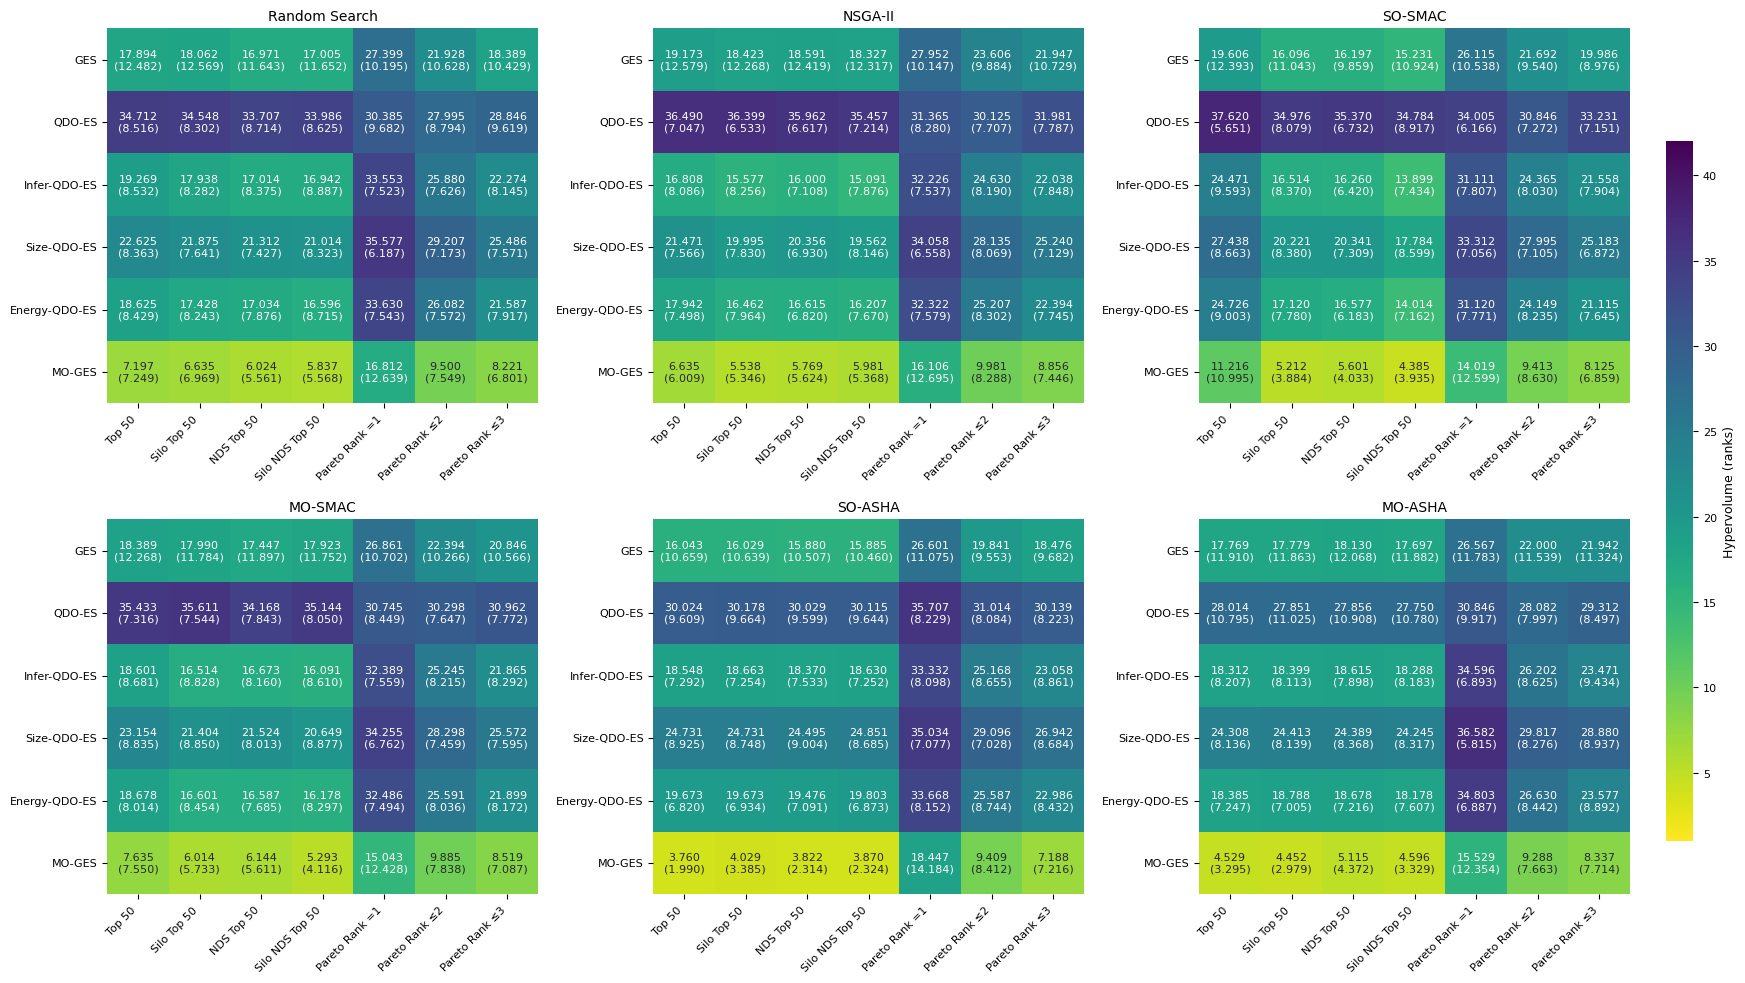

/tmp/ipykernel_14859/1787159355.py:90: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.92, 1])  # Leave room for colorbar


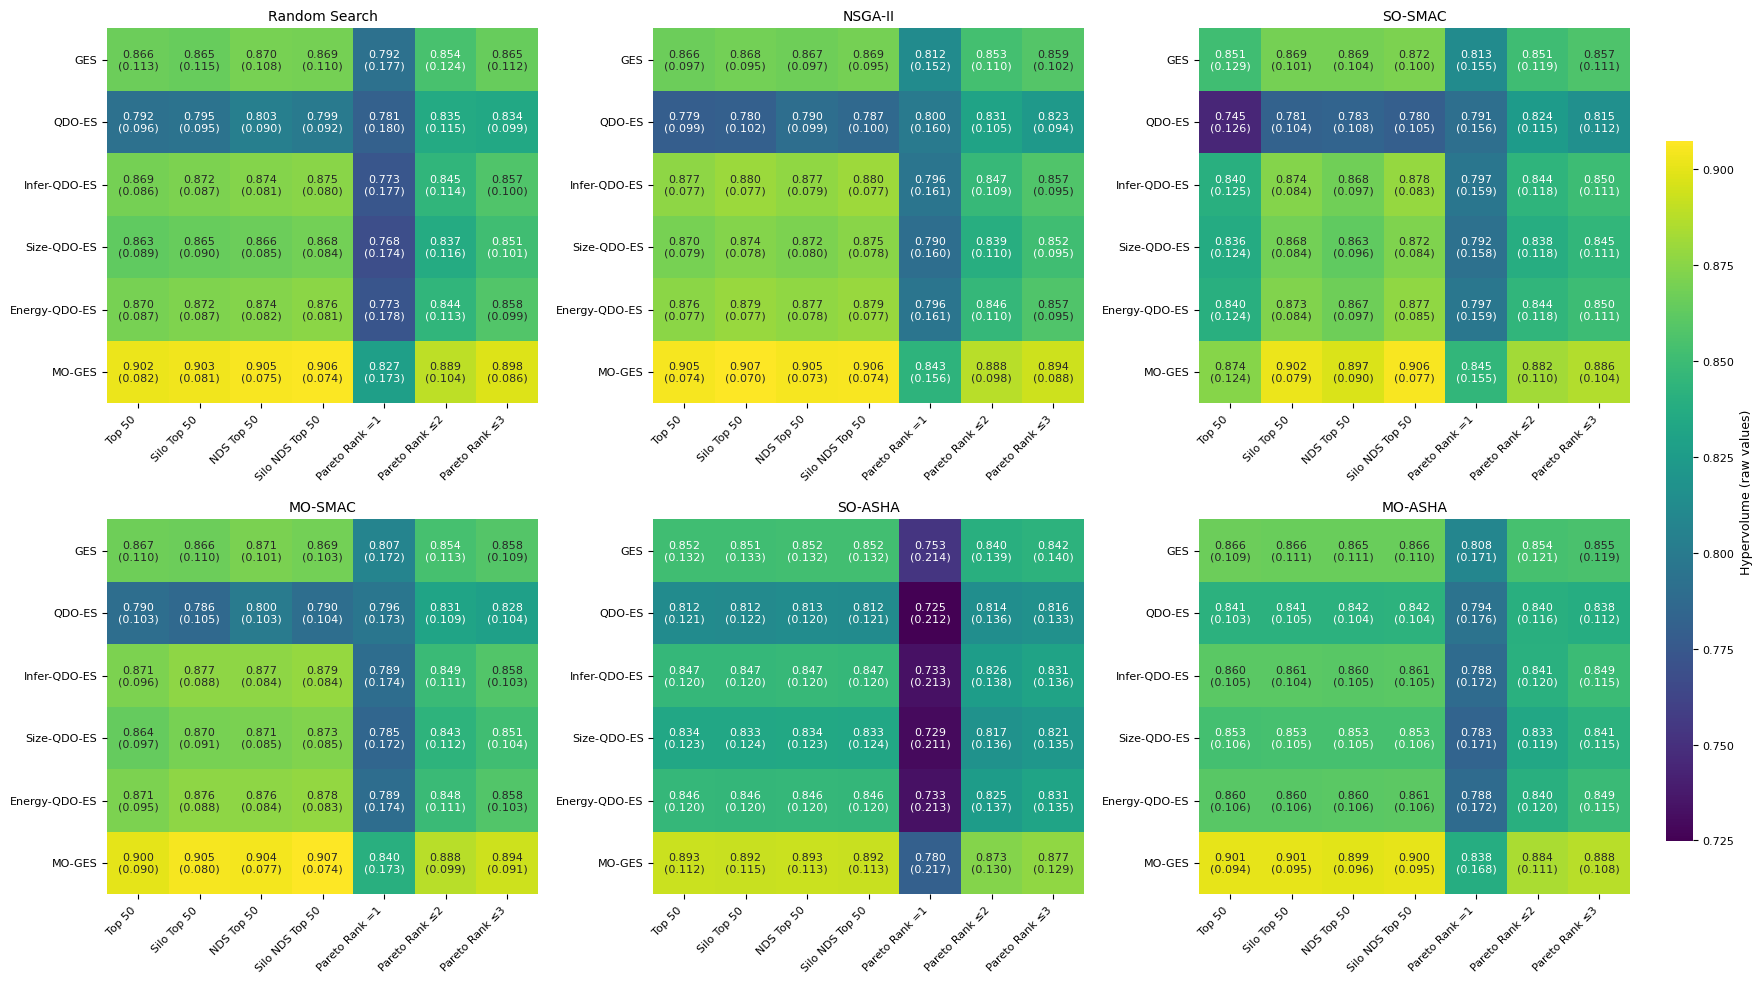

In [15]:
compare_pruning_full(task_ids, results_arr, frequency="no-boost", metric="Hypervolume")
compare_pruning_full(task_ids, results_arr, frequency="no-boost", metric="Hypervolume", use_ranks=False)

/tmp/ipykernel_14859/1787159355.py:90: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.92, 1])  # Leave room for colorbar


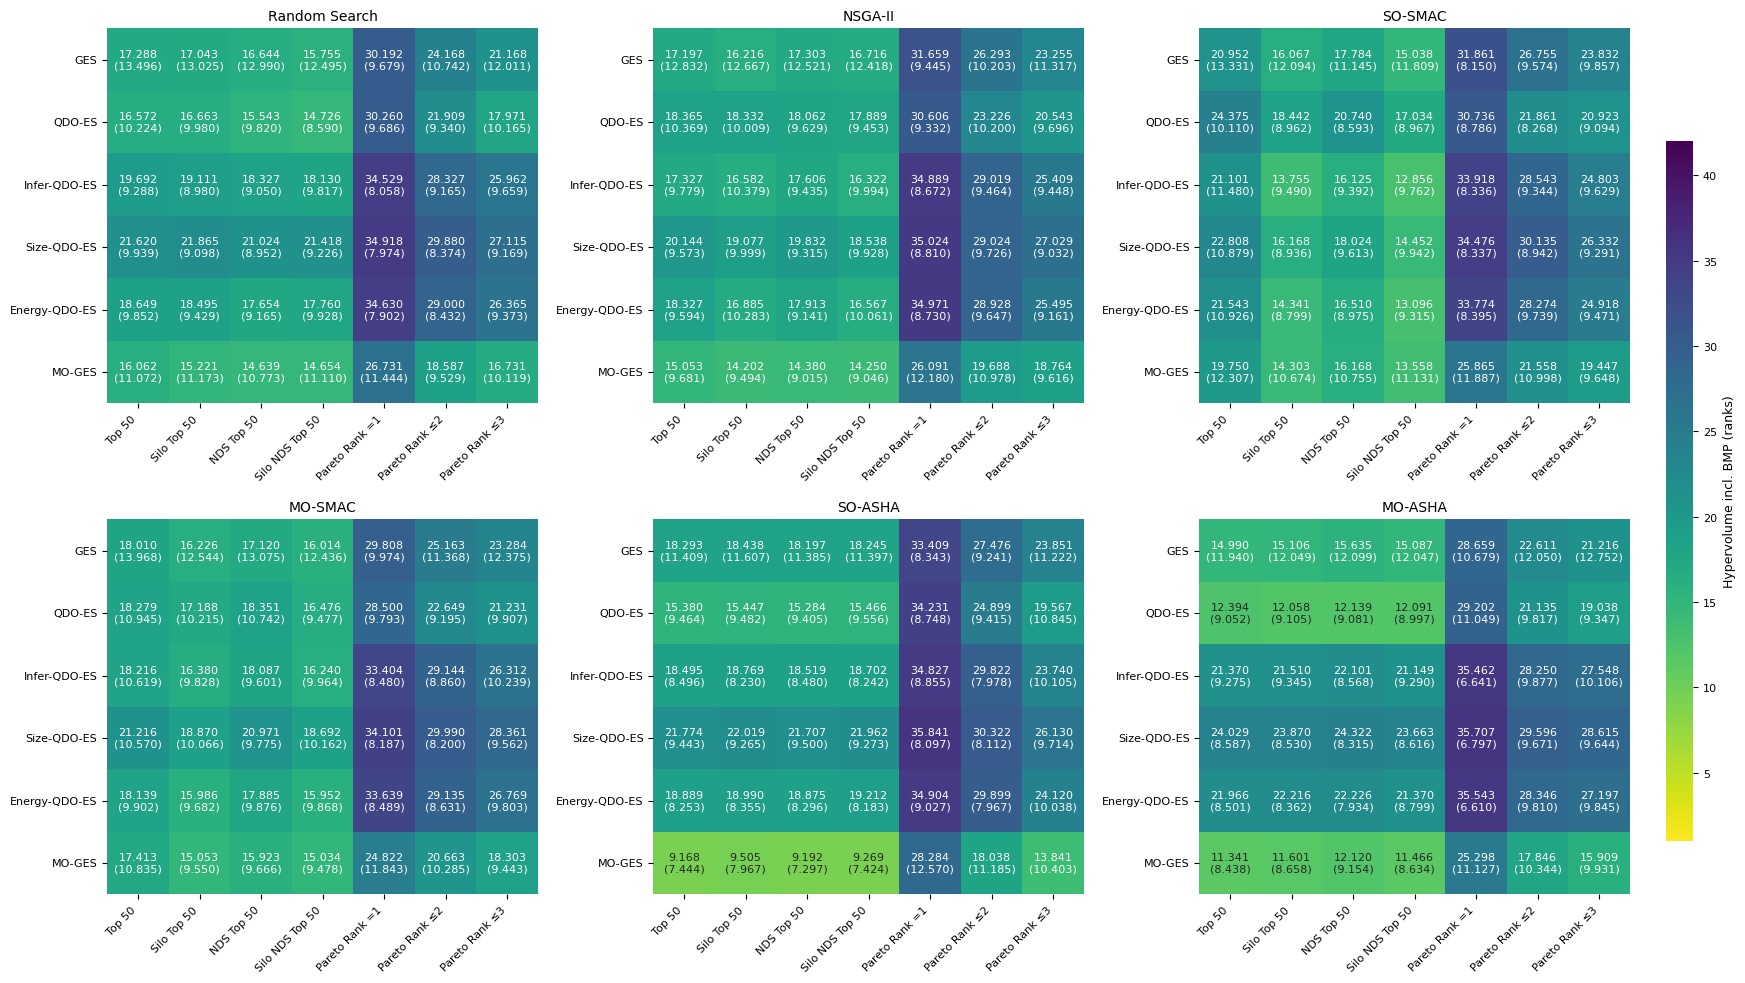

/tmp/ipykernel_14859/1787159355.py:90: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.92, 1])  # Leave room for colorbar


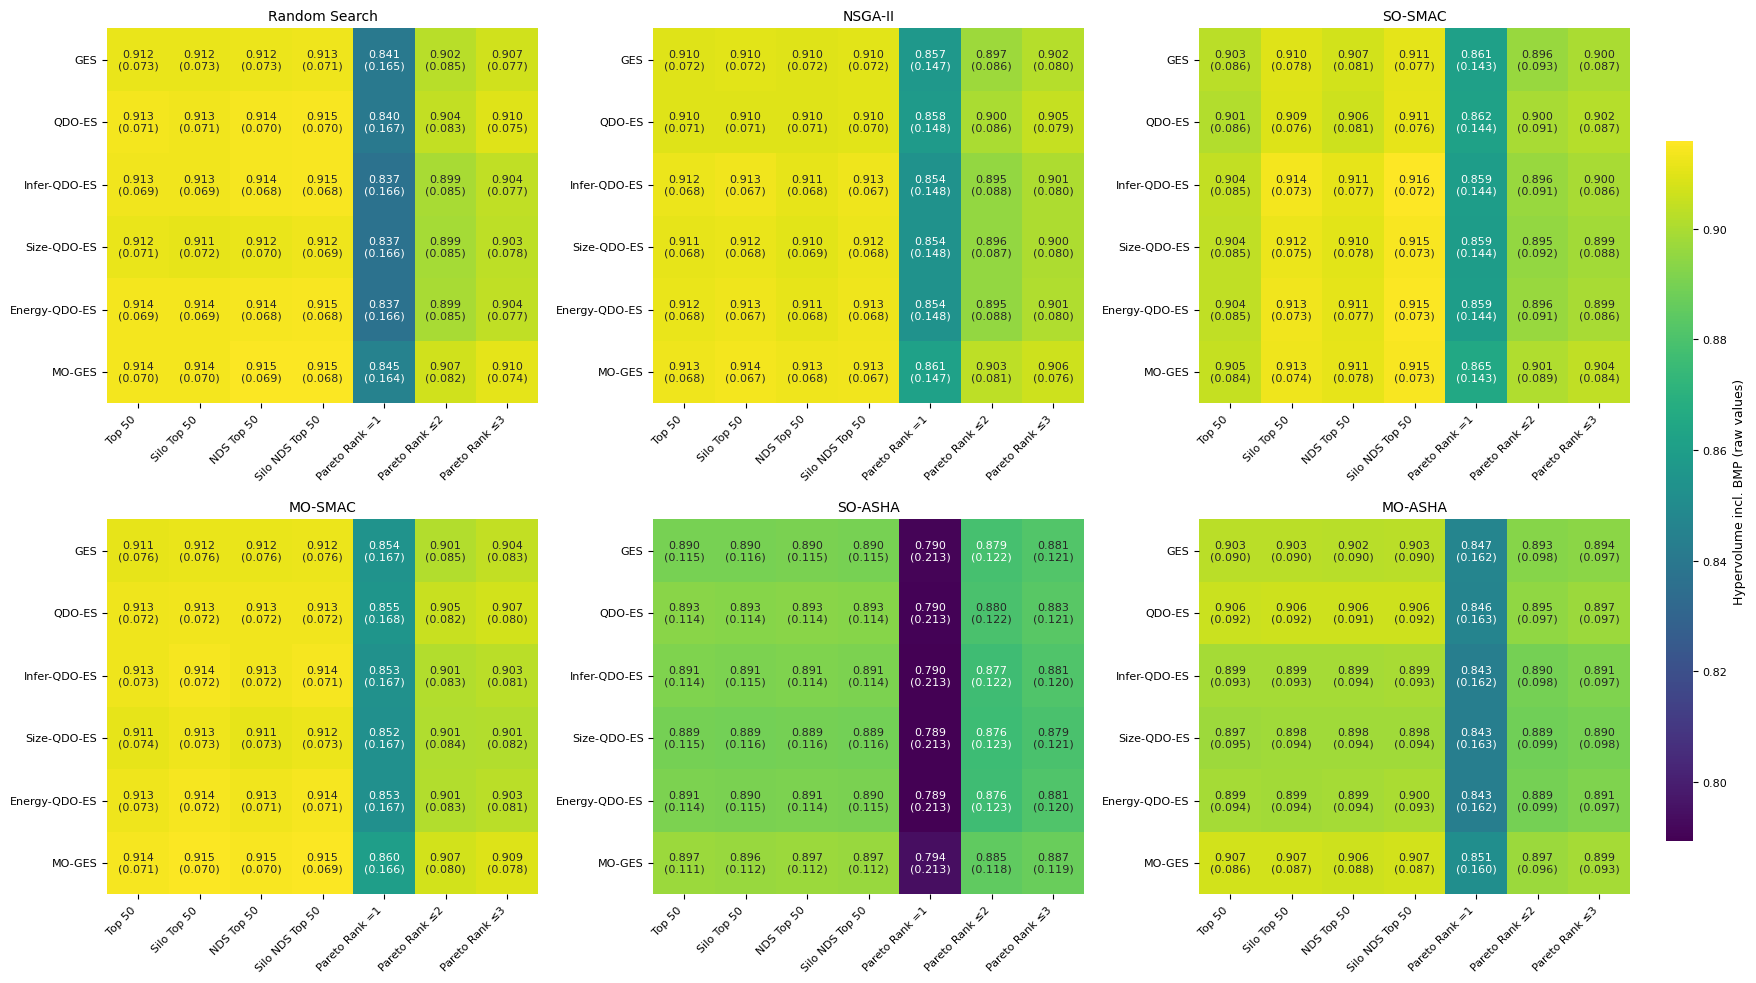

In [16]:
compare_pruning_full(task_ids, results_arr, frequency="no-boost", metric="Hypervolume incl. BMP")
compare_pruning_full(task_ids, results_arr, frequency="no-boost", metric="Hypervolume incl. BMP", use_ranks=False)

/tmp/ipykernel_14859/1787159355.py:90: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.92, 1])  # Leave room for colorbar


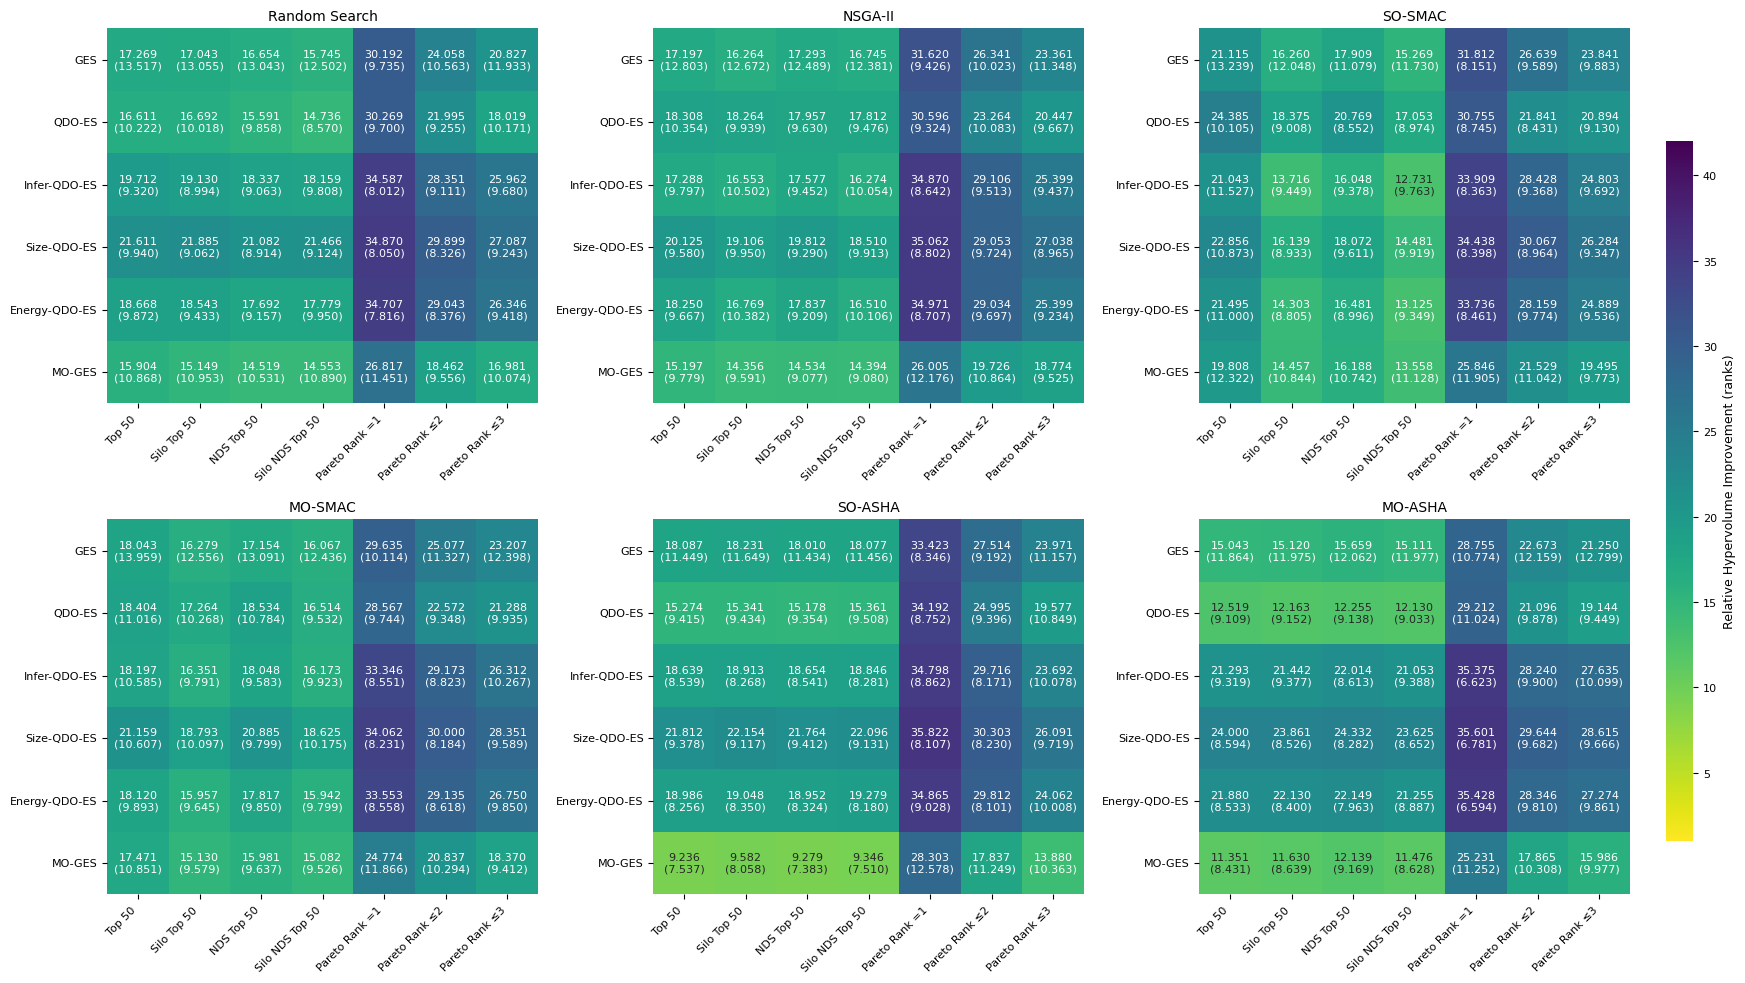

/tmp/ipykernel_14859/1787159355.py:90: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.92, 1])  # Leave room for colorbar


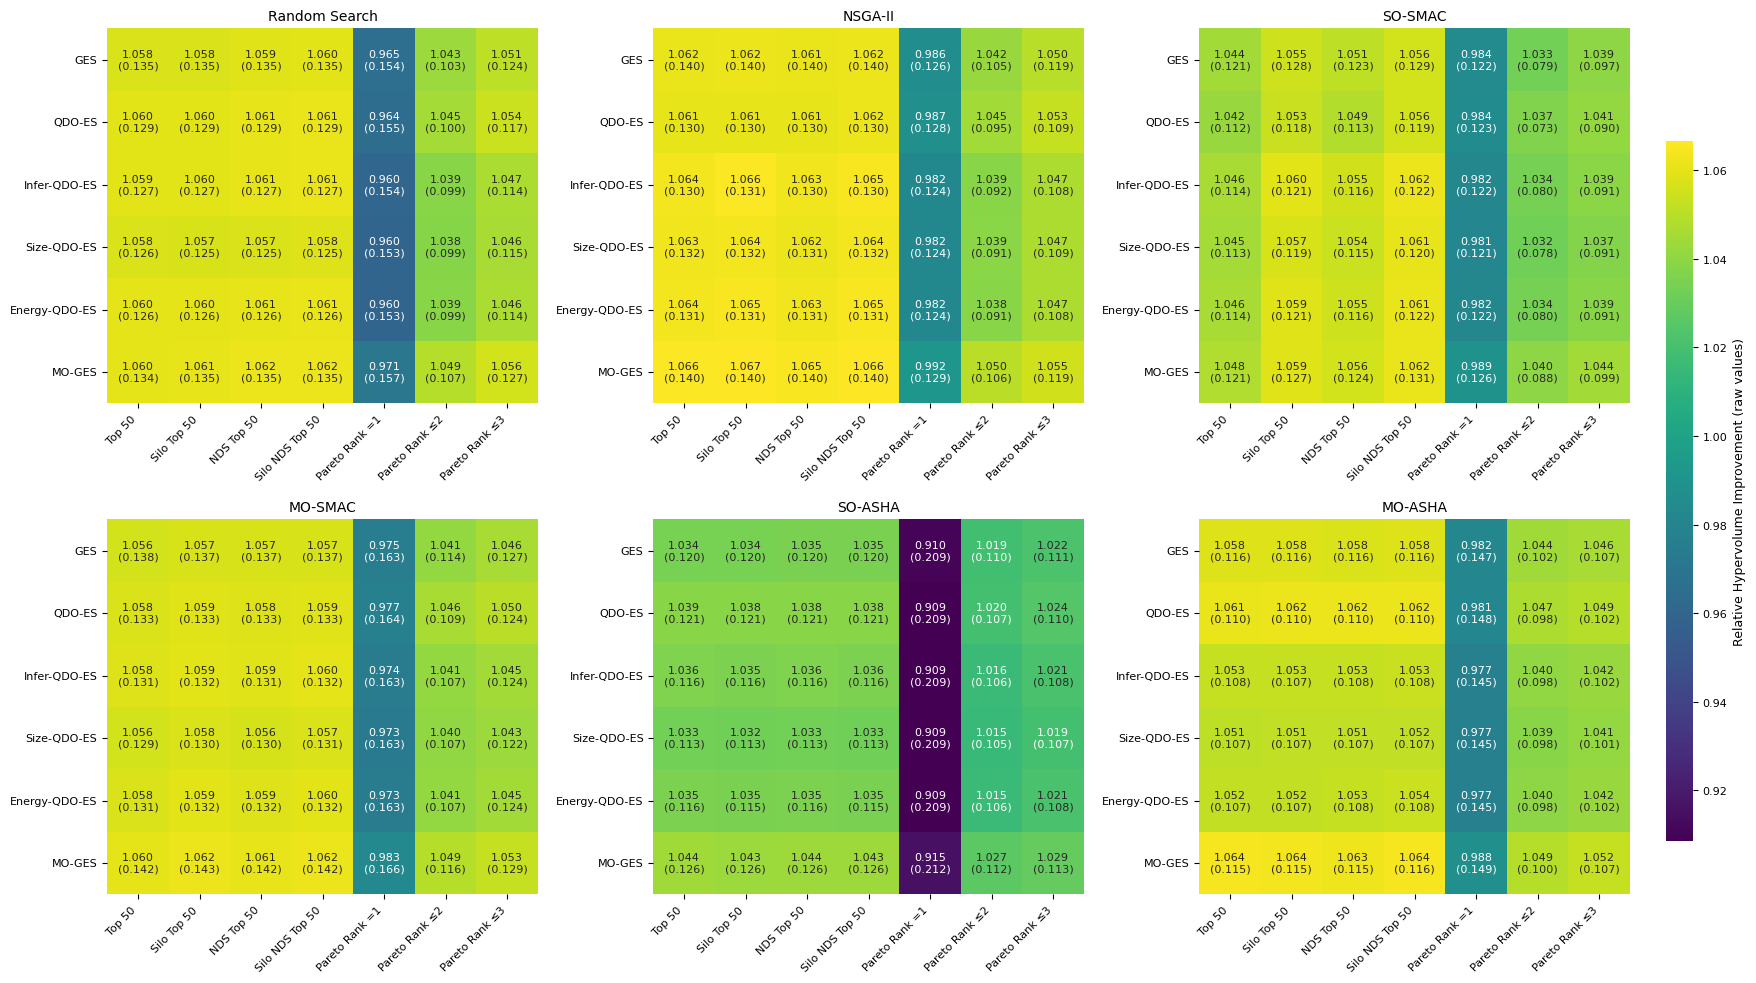

In [17]:
compare_pruning_full(task_ids, results_arr, frequency="no-boost", metric="Relative Hypervolume Improvement")
compare_pruning_full(task_ids, results_arr, frequency="no-boost", metric="Relative Hypervolume Improvement", use_ranks=False)

/tmp/ipykernel_14859/1787159355.py:90: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.92, 1])  # Leave room for colorbar


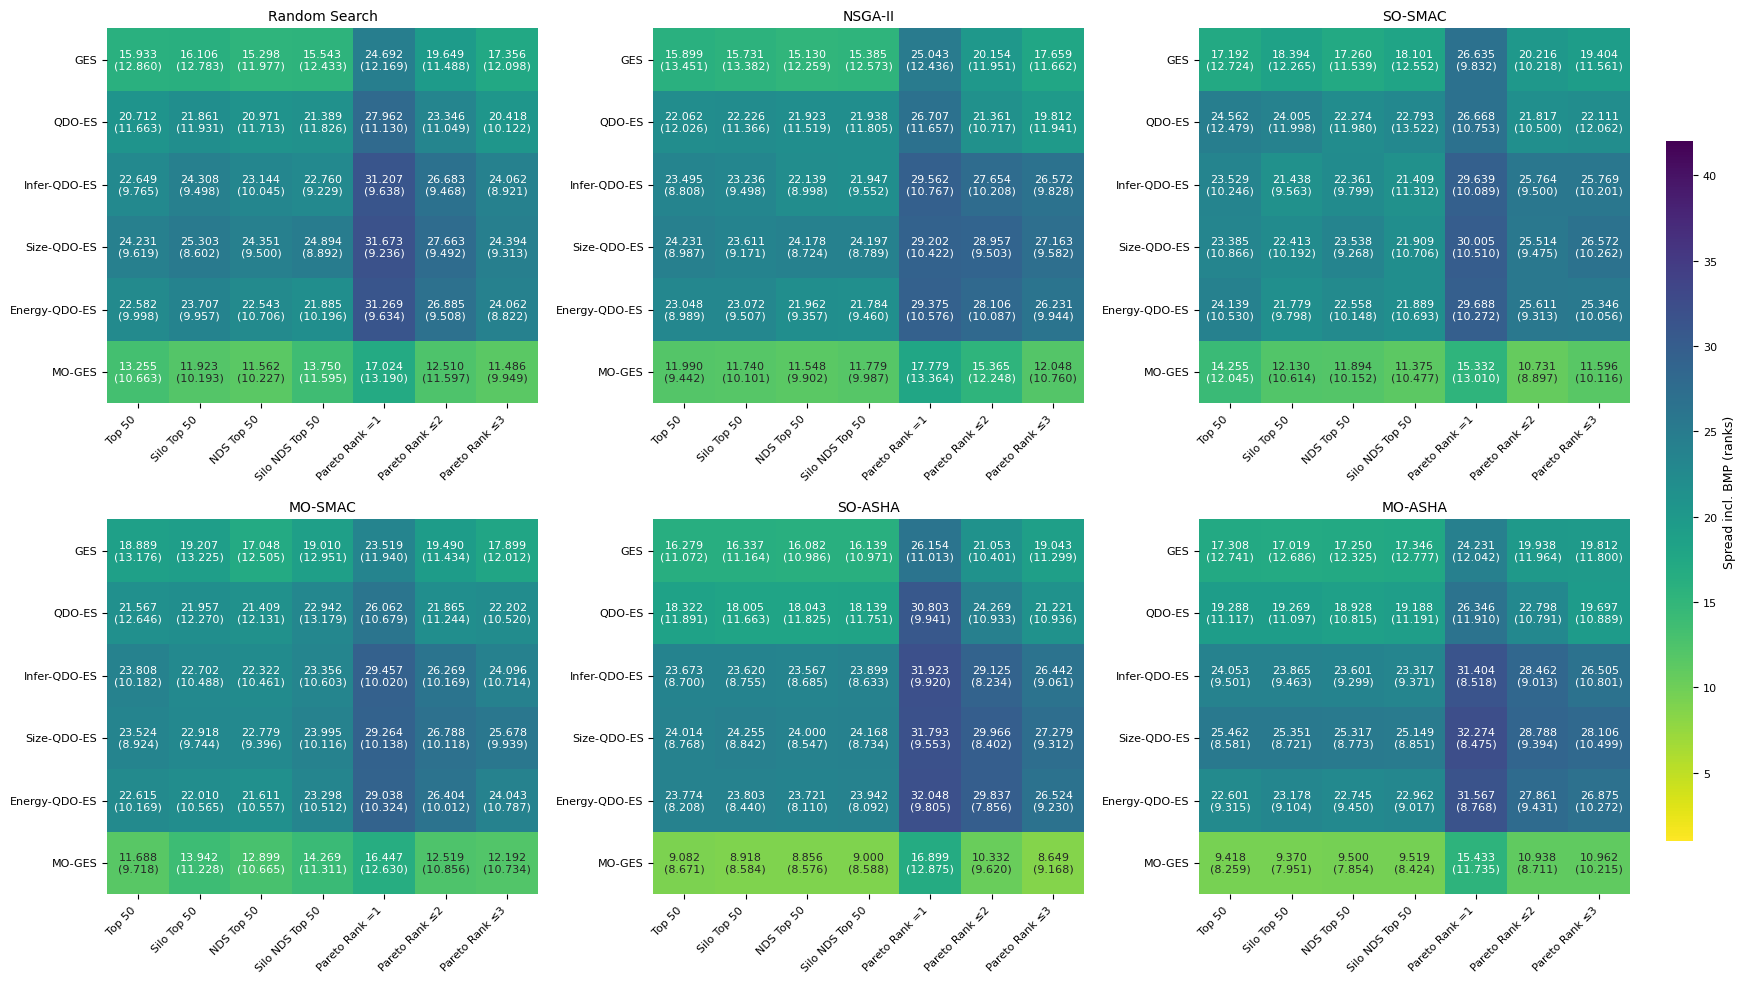

/tmp/ipykernel_14859/1787159355.py:90: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.92, 1])  # Leave room for colorbar


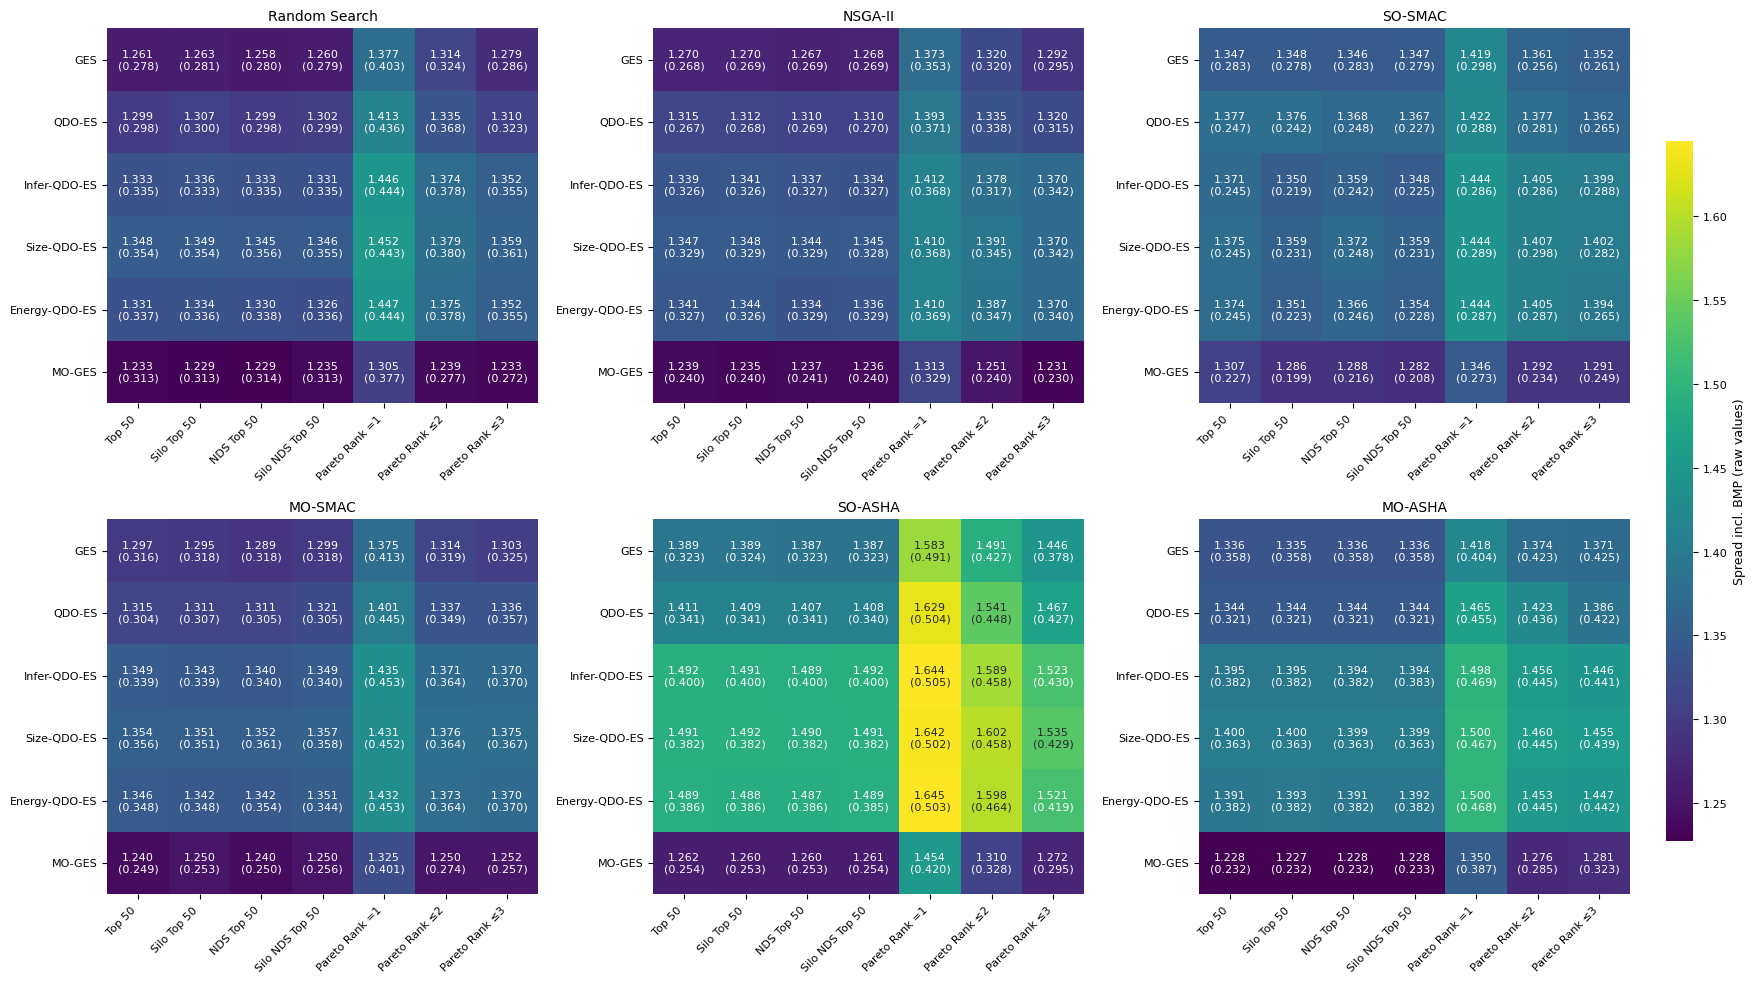

In [18]:
compare_pruning_full(task_ids, results_arr, frequency="no-boost", metric="Spread incl. BMP", mode="min")
compare_pruning_full(task_ids, results_arr, frequency="no-boost", metric="Spread incl. BMP", use_ranks=False, mode="min")

In [19]:
def compare_pruning_tradeoffs(task_ids, results_arr, frequency):
    metrics = ["Number of Models", "Runtime Ensembling", "Sum of Prediction Times"]
    fig, ax = plt.subplots(figsize=(12, 5), ncols=len(metrics), nrows=1, sharey=True)
    data = results_arr[freq_to_idx[frequency]]  # shape: (104, 6, 5, 6, 7, 11)
    data = data[:, :, :, :, :, [RESULTS_ORDER.index(m) for m in metrics]]  # shape: (104, 6, 5, 6, 7, 4)
    data = data.reshape((-1, 7, len(metrics)))  
    ax = ax.flatten()
    for i, metric in enumerate(metrics):
        data_metric = data[:, PRUNE_ORDER_IDX, i]  # shape: (104*6*5*6, 7)
        data_metric = data_metric[np.where(data_metric > 0)[0]]
        data_relative = data_metric / data_metric[:, [PRUNE_ORDER.index("nd_50_silo")]]  # relative to top_50
        
        indices_used = [4, 5, 6]  # top_50, nd_first_pareto, nd_second_pareto, nd_third_pareto
        data_relative = data_relative[:, indices_used]
        prune_order_used = [PRUNE_ORDER[i] for i in indices_used]

        mean = np.mean(data_relative, axis=0)
        std = np.std(data_relative, axis=0)
        ax[i].boxplot(data_relative, labels=[PRUNING_METHODS_DICT[p] for p in prune_order_used], showfliers=False)
        ax[i].plot(1+np.arange(len(mean)), mean, label="Mean")
        ax[i].fill_between(1+np.arange(len(mean)), mean-std, mean+std, alpha=0.2, label="Std Dev")
        ax[i].set_xticks(1+np.arange(len(mean)))
        ax[i].set_xticklabels([PRUNING_METHODS_DICT[p] for p in prune_order_used], rotation=45, ha="right", fontsize=8)
        ax[i].set_title(f"{metric}")
        if i== 0:
            ax[i].set_ylabel("Relative to Silo NDS Top 50")
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_14859/2613595042.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[i].boxplot(data_relative, labels=[PRUNING_METHODS_DICT[p] for p in prune_order_used], showfliers=False)
/tmp/ipykernel_14859/2613595042.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[i].boxplot(data_relative, labels=[PRUNING_METHODS_DICT[p] for p in prune_order_used], showfliers=False)
/tmp/ipykernel_14859/2613595042.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[i].boxplot(data_relative, labels=[PRUNING_METHODS_DICT[p] for p in prune_order_used], showfliers=False)


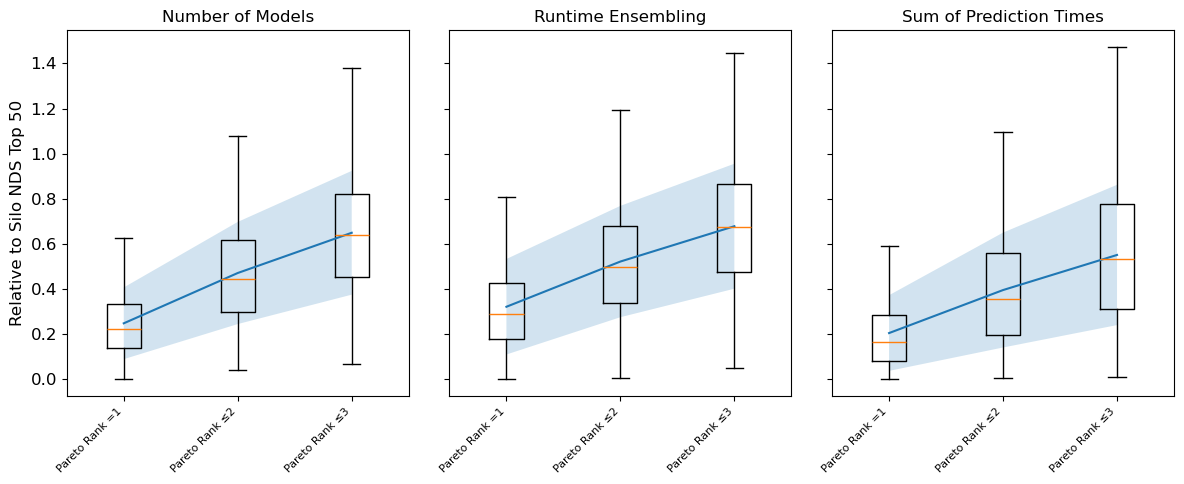

In [20]:
compare_pruning_tradeoffs(task_ids, results_arr, frequency="no-boost")

# Wichtige Takaways
- ASHA produziert kaum > 50, daher kaum Unterschied bei den ersten vier Methoden
- Ansonsten: Silo Approaches besser als non-silo und NDS teilweise besser als SO-TOP
    - Begründung evtl: Relativ ausgeglichener Search Space => Daher NDS und Silo
- Pareto Rank Filter zwar schwächer, aber Trade-Off mit Runtime/Prediction Resources für ensemble predictions ist nennenswert



=> Ab jetzt: Nur noch SiloNDS Top 50 betrachte

# Vergleich der BMG und Ensembling Methoden
- Matrix Plot BMG x Ensembling Methods

In [21]:
def plot_bmg_ensembling(task_ids, results_arr, frequency="no-boost", metric="Hypervolume", use_ranks=True, mode="max"):
    metric_vals = np.take(results_arr, RESULTS_ORDER.index(metric), axis=-1)
    freq_idx = freq_to_idx[frequency]
    print(freq_idx)
    metric_vals = np.take(metric_vals, freq_idx, axis=0)  # shape: (104, 6, 5, 6, 7)
    metric_vals_mean = np.mean(metric_vals, axis=2)  # shape: (104, 6, 6, 7)
    metric_vals_mean = np.take(metric_vals_mean, prune_to_idx["nd_50_silo"], axis=3)  # shape: (104, 6, 6)
    
    task_ids = np.array([task_id_to_idx[t] for t in task_ids])
    metric_vals_mean = metric_vals_mean[task_ids]  # shape: (len(task_ids), 6, 6)

    if use_ranks:
        metric_vals_reshape = metric_vals_mean.reshape((len(task_ids), -1))  # shape: (104, 36)
        ranks = compute_ranks(metric_vals_reshape, mode=mode, axis=1)  # shape: (104, 36)
        ranks = ranks.reshape((len(task_ids), len(BMG_METHODS), len(ENSEMBLING_METHODS)))  # shape: (104, 6, 6)
        mean_ranks = ranks.mean(axis=0)  # shape: (6, 6)
        std_ranks = ranks.std(axis=0)    # shape: (6, 6)
        mean_ranks = mean_ranks[np.ix_([bmg_to_idx[b] for b in BMG_METHODS], [es_to_idx[e] for e in ENSEMBLING_METHODS])]
        std_ranks = std_ranks[np.ix_([bmg_to_idx[b] for b in BMG_METHODS], [es_to_idx[e] for e in ENSEMBLING_METHODS])]

        # Combine mean and std into formatted strings
        annot = np.empty(mean_ranks.shape, dtype=object)
        for i in range(mean_ranks.shape[0]):
            for j in range(mean_ranks.shape[1]):
                annot[i, j] = f"{mean_ranks[i, j]:.3f}\n({std_ranks[i, j]:.3f})"
        sns.heatmap(
            mean_ranks,
            annot=annot,
            fmt="",
            cmap="viridis_r",
            vmin=1,
            vmax=len(BMG_METHODS) * len(ENSEMBLING_METHODS),
            annot_kws={"size": 8},
        )
    else:
        mean_vals = metric_vals_mean.mean(axis=0)  # shape: (6, 6)
        std_vals = metric_vals_mean.std(axis=0)    # shape: (6, 6)
        mean_vals = mean_vals[np.ix_([bmg_to_idx[b] for b in BMG_METHODS], [es_to_idx[e] for e in ENSEMBLING_METHODS])]
        std_vals = std_vals[np.ix_([bmg_to_idx[b] for b in BMG_METHODS], [es_to_idx[e] for e in ENSEMBLING_METHODS])]

        # Combine mean and std into formatted strings
        annot = np.empty(mean_vals.shape, dtype=object)
        for i in range(mean_vals.shape[0]):
            for j in range(mean_vals.shape[1]):
                annot[i, j] = f"{mean_vals[i, j]:.3f}\n({std_vals[i, j]:.3f})"
        sns.heatmap(
            mean_vals,
            annot=annot,
            fmt="",
            cmap="viridis",
            vmin=mean_vals.min(),
            vmax=mean_vals.max(),
            annot_kws={"size": 8},
        )
    plt.title(f"{metric} {'(ranks)' if use_ranks else '(raw values)'} - Pruning: Silo NDS Top 50")
    plt.xticks(ticks=np.arange(len(ENSEMBLING_METHODS))+0.5, labels=[ENSEMBLING_METHODS_DICT[e] for e in ENSEMBLING_METHODS], rotation=45, ha="right", fontsize=8)
    plt.yticks(ticks=np.arange(len(BMG_METHODS))+0.5, labels=[BMG_METHODS_DICT[b] for b in BMG_METHODS], rotation=0, fontsize=8)
    plt.tight_layout()
    plt.show()


1


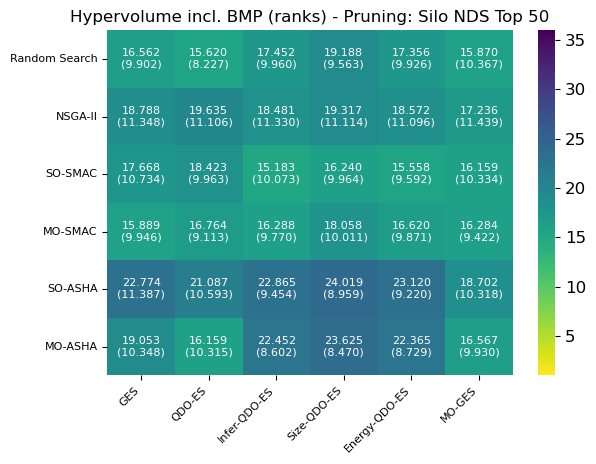

1


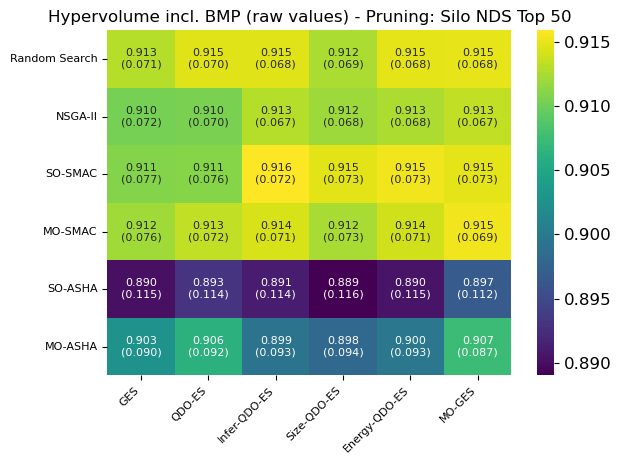

1


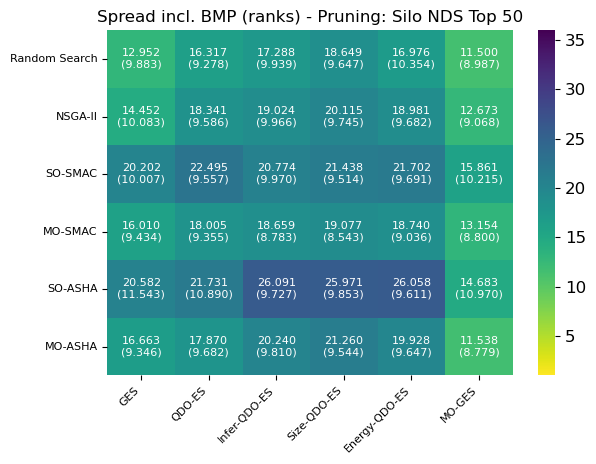

1


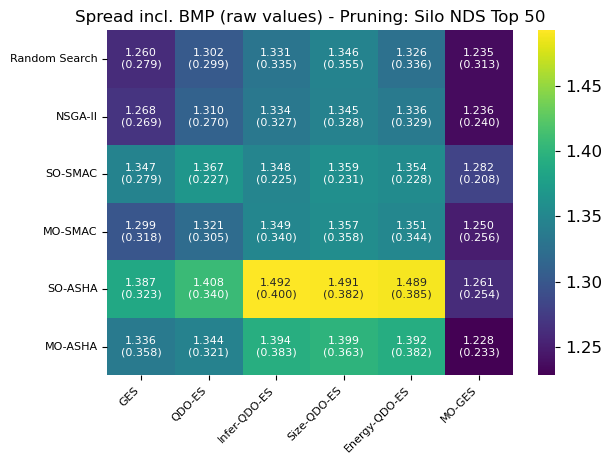

In [22]:
plot_bmg_ensembling(task_ids, results_arr, frequency="no-boost", metric="Hypervolume incl. BMP")
plot_bmg_ensembling(task_ids, results_arr, frequency="no-boost", metric="Hypervolume incl. BMP", use_ranks=False)
plot_bmg_ensembling(task_ids, results_arr, frequency="no-boost", metric="Spread incl. BMP", mode="min")
plot_bmg_ensembling(task_ids, results_arr, frequency="no-boost", metric="Spread incl. BMP", use_ranks=False, mode="min")

1


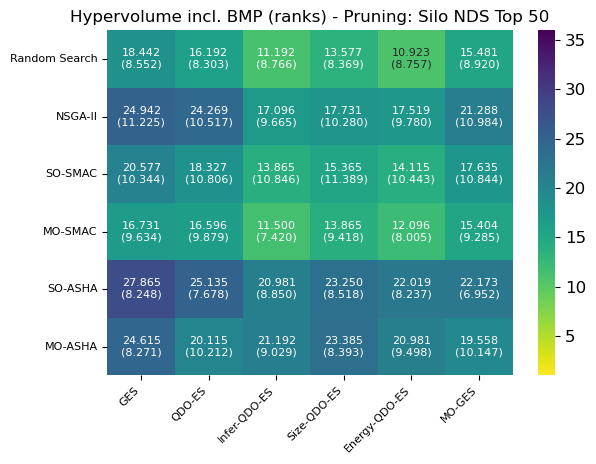

1


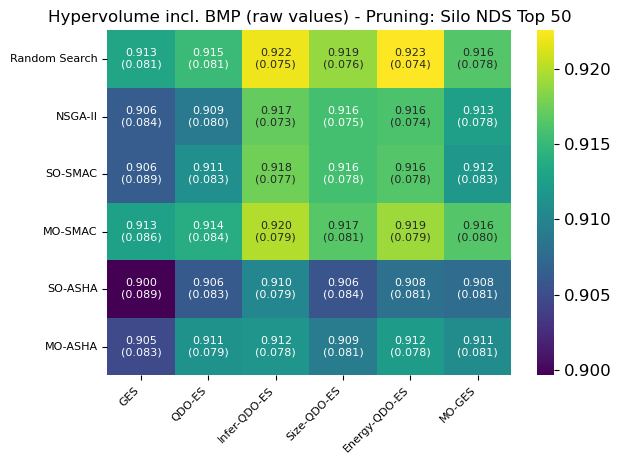

1


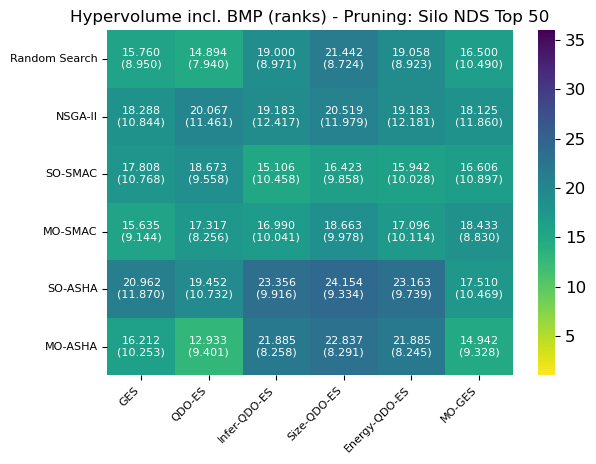

1


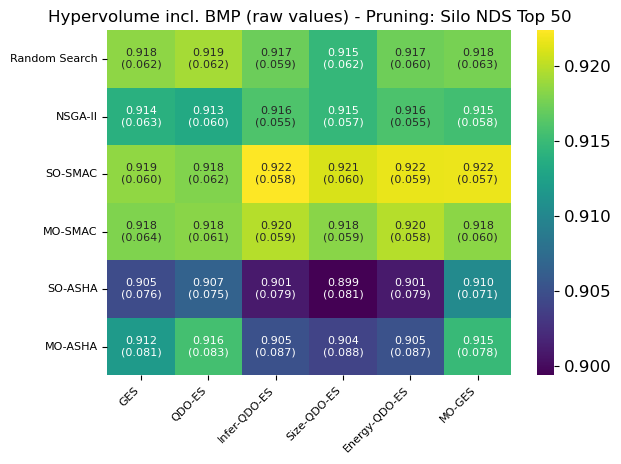

1


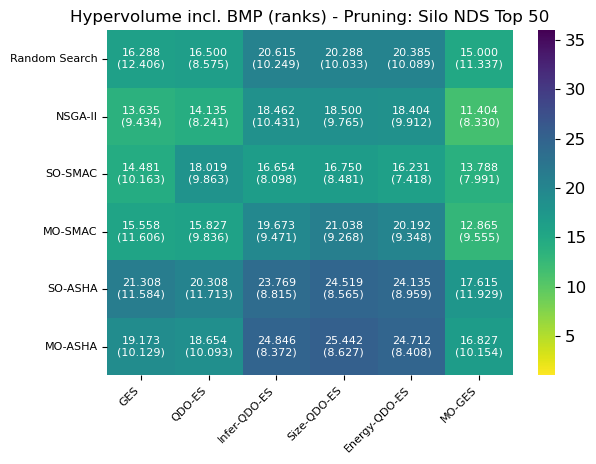

1


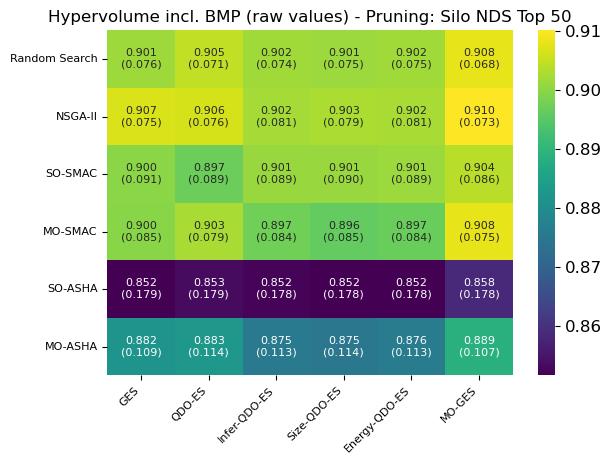

In [23]:
fast = get_group_task_ids("fast")
plot_bmg_ensembling(fast, results_arr, frequency="no-boost", metric="Hypervolume incl. BMP")
plot_bmg_ensembling(fast, results_arr, frequency="no-boost", metric="Hypervolume incl. BMP", use_ranks=False)
medium = get_group_task_ids("medium")
plot_bmg_ensembling(medium, results_arr, frequency="no-boost", metric="Hypervolume incl. BMP")
plot_bmg_ensembling(medium, results_arr, frequency="no-boost", metric="Hypervolume incl. BMP", use_ranks=False)
slow = get_group_task_ids("slow")
plot_bmg_ensembling(slow, results_arr, frequency="no-boost", metric="Hypervolume incl. BMP")
plot_bmg_ensembling(slow, results_arr, frequency="no-boost", metric="Hypervolume incl. BMP", use_ranks=False)

In [50]:
import autorank
from critdd import Diagrams
from colors import COLORS

COLOR_LIST= list(COLORS.values())

def compute_nonsig_groups(mean_ranks, cd):
    """
    mean_ranks: array of shape (M,) with mean ranks for each treatment
    cd: critical distance
    
    Returns a list of groups (each group is a list of indices)
    that are NOT significantly different.
    """
    M = len(mean_ranks)
    
    # Sort indices by mean rank
    sorted_idx = np.argsort(mean_ranks)
    sorted_ranks = mean_ranks[sorted_idx]
    
    groups = []
    i = 0
    while i < M:
        group = [sorted_idx[i]]
        j = i + 1
        while j < M:
            # If difference between ranks <= CD, treatments are NOT significantly different
            if sorted_ranks[j] - sorted_ranks[i] <= cd:
                group.append(sorted_idx[j])
                j += 1
            else:
                break
        groups.append(group)
        i = i+1  # move to next group

    def is_subset(small, big):
        return all(item in big for item in small)

    groups = [g for g in groups if len(g) > 1]
    sorted_groups = sorted(groups, key=lambda x: len(x), reverse=False)

    remove_indices = []
    for i in range(len(sorted_groups)):
        if any(is_subset(sorted_groups[i], sorted_groups[j]) for j in range(len(sorted_groups)) if j != i):
            remove_indices.append(i)

    return [sorted_groups[i] for i in range(len(sorted_groups)) if i not in remove_indices]


def create_cd_2d(mean_ranks, cd, diagram_names, treatment_names, x_label=None):
    fig, ax = plt.subplots(figsize=(9, 6))

    # Remove borders and ticks
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(length=0)

    # Set ticks and grid
    ax.set_xticks(1 + np.arange(len(treatment_names)))  # x grid every 1 unit
    ax.set_yticks(np.arange(len(diagram_names)))
    ax.grid(True, alpha=0.6)
    ax.invert_xaxis()  # Invert x-axis
    ax.set_xlim(1, len(treatment_names)+.005)

    # Y-axis labels
    ax.set_yticklabels(diagram_names[::-1], ha="right", fontsize=14)
    ax.set_xticklabels(1 + np.arange(len(treatment_names)), fontsize=14)

    if x_label is not None:
        ax.set_xlabel(x_label, fontsize=16)

    # Scatter plot
    treatment_markers = ["s","o", "*","x","^","2"]
    treatment_colors = COLOR_LIST

    scatter_handles = []

    for i, diagram_name in enumerate(diagram_names):
        ranks = mean_ranks[i]
        cd_val = cd[i]

        groups_nonsig = compute_nonsig_groups(ranks, cd_val)
        for i_group, group in enumerate(groups_nonsig):
            group_ranks = ranks[group]
            x_start = group_ranks.min()
            x_end = group_ranks.max()
            y_pos = len(diagram_names) - 1 - i - 0.2 - i_group * 0.1
            ax.hlines(y=y_pos, xmin=x_start, xmax=x_end, color='black', linewidth=1)
            #ax.vlines(x=x_start, ymin=y_pos, ymax=y_pos + 0.05, color='black', linewidth=1)
            #ax.vlines(x=x_end, ymin=y_pos, ymax=y_pos + 0.05, color='black', linewidth=1)

        for j, treatment_name in enumerate(treatment_names):
            sc = ax.scatter(
                ranks[j], len(diagram_names) - 1 - i, 
                marker=treatment_markers[j % len(treatment_markers)],
                color=treatment_colors[j % len(treatment_colors)], 
                s=100, alpha=1,
            )
            scatter_handles.append(sc)
            groups_with_j_indices = [i for i, g in enumerate(groups_nonsig) if j in g]
            max_index = max(groups_with_j_indices) if groups_with_j_indices else -1
            if max_index >= 0:
                ax.vlines(x=ranks[j], ymin=len(diagram_names) - 1 - i, ymax=len(diagram_names) - 1 - i - 0.2 - (max_index * 0.1), linewidth=1, color="black", linestyles="dotted")        

    # Legend outside to the right
    plt.legend(
        handles=scatter_handles[:len(treatment_names)],  # only scatter points
        labels=treatment_names,
        bbox_to_anchor=(1, 0.5),
        loc='center left',
        fontsize=14
    )

    plt.show()




def plot_cds(task_ids, results_arr, frequency="no-boost", metric="Hypervolume", mode="max"):
    metric_vals = np.take(results_arr, RESULTS_ORDER.index(metric), axis=-1)
    freq_idx = freq_to_idx[frequency]
    metric_vals = np.take(metric_vals, freq_idx, axis=0)  # shape: (104, 6, 5, 6, 7)
    metric_vals_mean = np.mean(metric_vals, axis=2)  # shape: (104, 6, 6, 7)
    metric_vals_mean = np.take(metric_vals_mean, prune_to_idx["nd_50_silo"], axis=3)  # shape: (104, 6, 6)

    fig, ax = plt.subplots(figsize=(15, 8), ncols=2, nrows=3)
    ax = ax.flatten()

    mean_ranks = []
    cds = []

    for i, bmg_method in enumerate(BMG_METHODS):
        i_bmg = bmg_to_idx[bmg_method]
        data = metric_vals_mean[:, i_bmg, :]  # shape: (104, 6)
        data = data[[task_id_to_idx[t] for t in task_ids]]  # shape: (len(task_ids), 6)
        data = data[:, [es_to_idx[e] for e in ENSEMBLING_METHODS]]  # shape: (len(task_ids), 6)
        metric_df = pd.DataFrame(data, columns=[ENSEMBLING_METHODS_DICT[e] for e in ENSEMBLING_METHODS])
        
        if mode == "min":
            metric_df = -metric_df

        result = autorank.autorank(metric_df, verbose=False)
        plt.rcParams.update({'font.size': 18})
        autorank.plot_stats(result, ax=ax[i], allow_insignificant=True)
        ax[i].set_title(BMG_METHODS_DICT[bmg_method], fontsize=16)

        mean_ranks.append(result.rankdf["meanrank"])
        cds.append(result.cd)

    fig.subplots_adjust(
        left=0.05,
        right=0.95,
        bottom=0.0,
        top=1.0,
        wspace=0.5,
        hspace=0.2
    )
    plt.show()

    mean_ranks_array = np.array([[mr_df[ENSEMBLING_METHODS_DICT[e]] for e in ENSEMBLING_METHODS] for mr_df in mean_ranks])

    create_cd_2d(
        mean_ranks_array,
        np.array(cds),
        diagram_names = [BMG_METHODS_DICT[m] for m in BMG_METHODS],
        treatment_names = [ENSEMBLING_METHODS_DICT[e] for e in ENSEMBLING_METHODS],
        x_label=f"Mean {metric} Rank"
    )


               meanrank    median       mad  ci_lower  ci_upper effect_size   magnitude effect_size_above magnitude_above
QDO-ES         5.538462  0.802415  0.054658   0.76734  0.843486         0.0  negligible               0.0      negligible
Size-QDO-ES    4.153846  0.890326  0.055274   0.84063  0.929718   -1.078754       large         -1.078754           large
Infer-QDO-ES   3.298077  0.892608   0.05051   0.85195  0.932812   -1.156011       large         -0.029069      negligible
GES            3.230769  0.897284  0.048248  0.852765  0.935851   -1.241232       large          -0.06386      negligible
Energy-QDO-ES  3.192308  0.894781  0.048798  0.853229  0.936006   -1.202452       large          0.034796      negligible
MO-GES         1.586538  0.929116  0.042992  0.886329  0.958966   -1.737945       large         -0.503585          medium
               meanrank    median       mad  ci_lower  ci_upper effect_size   magnitude effect_size_above magnitude_above
QDO-ES         5.759615 

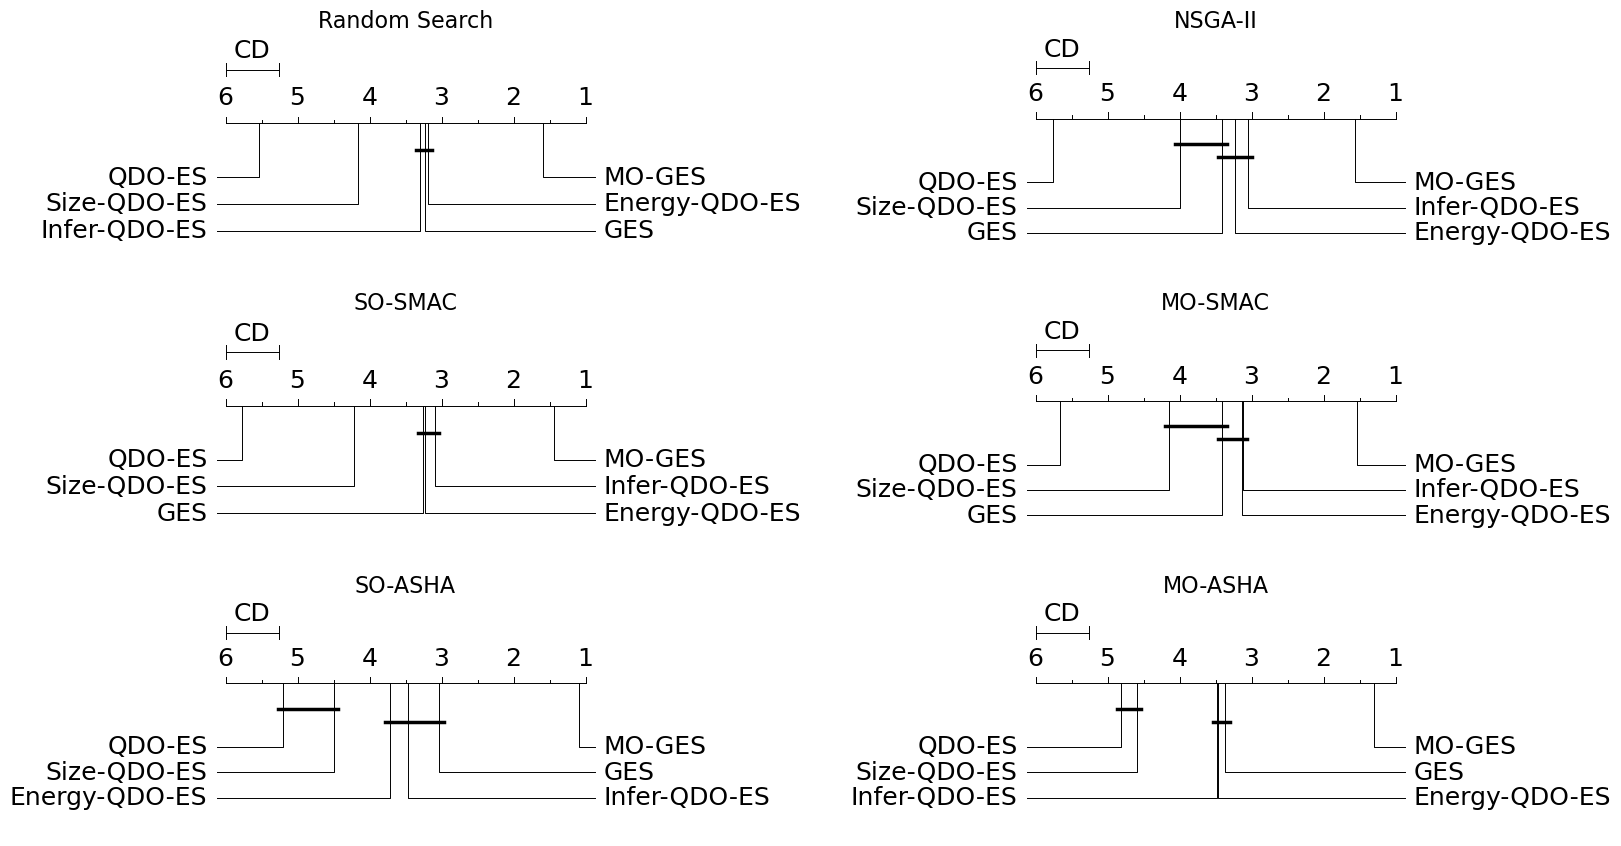

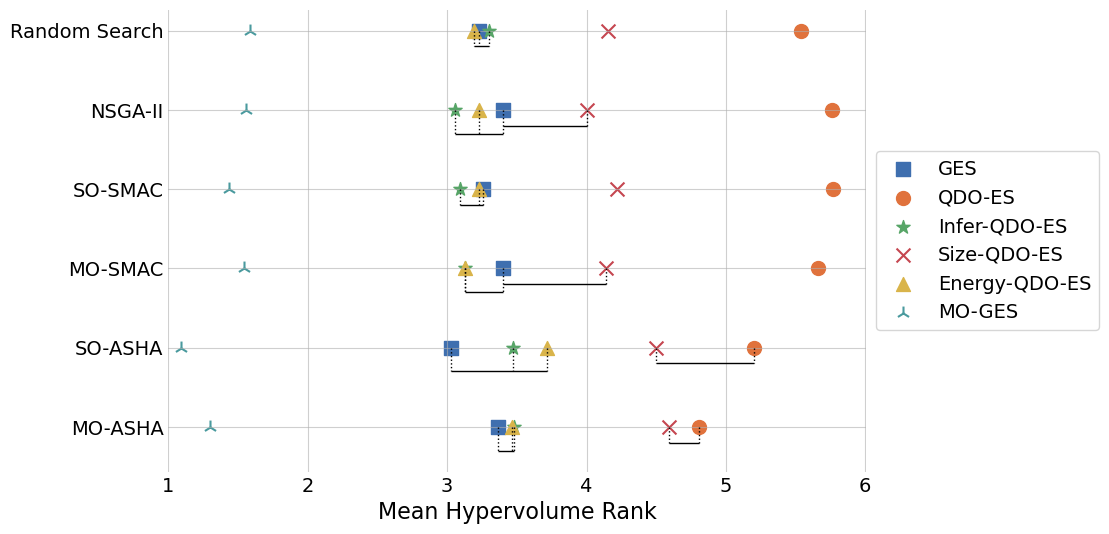

In [51]:
plot_cds(task_ids, results_arr, frequency="no-boost", metric="Hypervolume", mode="max")

               meanrank    median       mad  ci_lower  ci_upper effect_size   magnitude effect_size_above magnitude_above
Size-QDO-ES    4.302885  0.932148  0.040104  0.892379  0.961522         0.0  negligible               0.0      negligible
Infer-QDO-ES   3.605769  0.932944  0.039668  0.894775  0.961697   -0.013458  negligible         -0.013458      negligible
Energy-QDO-ES  3.596154  0.932665  0.040885  0.894775  0.961697   -0.008602  negligible          0.004678      negligible
GES            3.206731  0.939245  0.038849  0.892554  0.965665   -0.121243  negligible         -0.111296      negligible
QDO-ES         3.168269  0.938619  0.038607  0.892382   0.96544   -0.110885  negligible          0.010899      negligible
MO-GES         3.120192  0.941891  0.038588  0.896813  0.964831   -0.166982  negligible         -0.057167      negligible
               meanrank    median       mad  ci_lower  ci_upper effect_size   magnitude effect_size_above magnitude_above
Size-QDO-ES    3.875000 

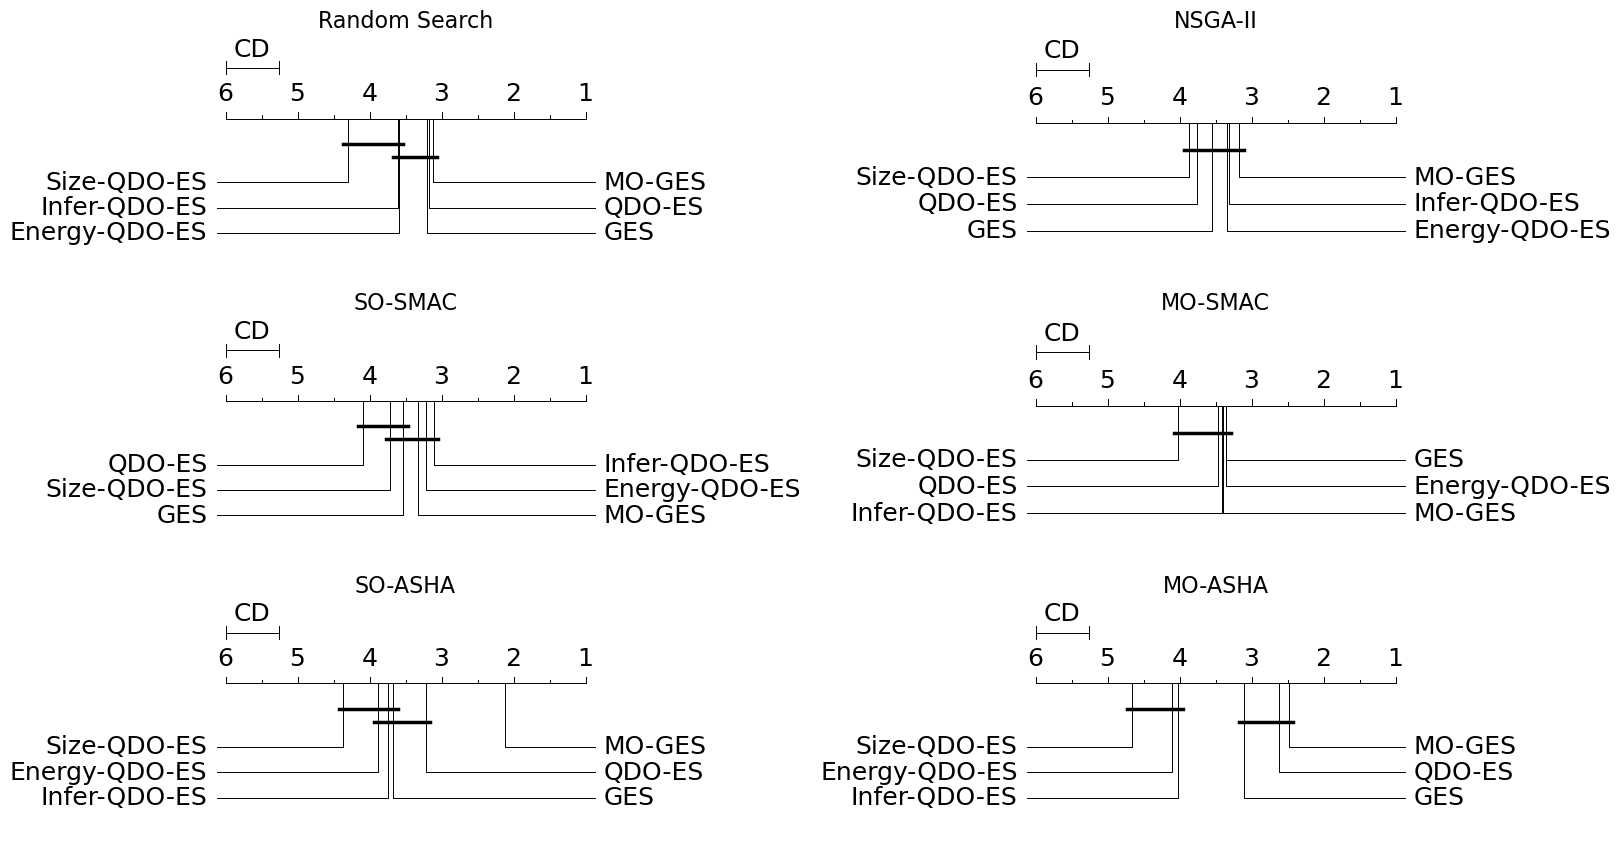

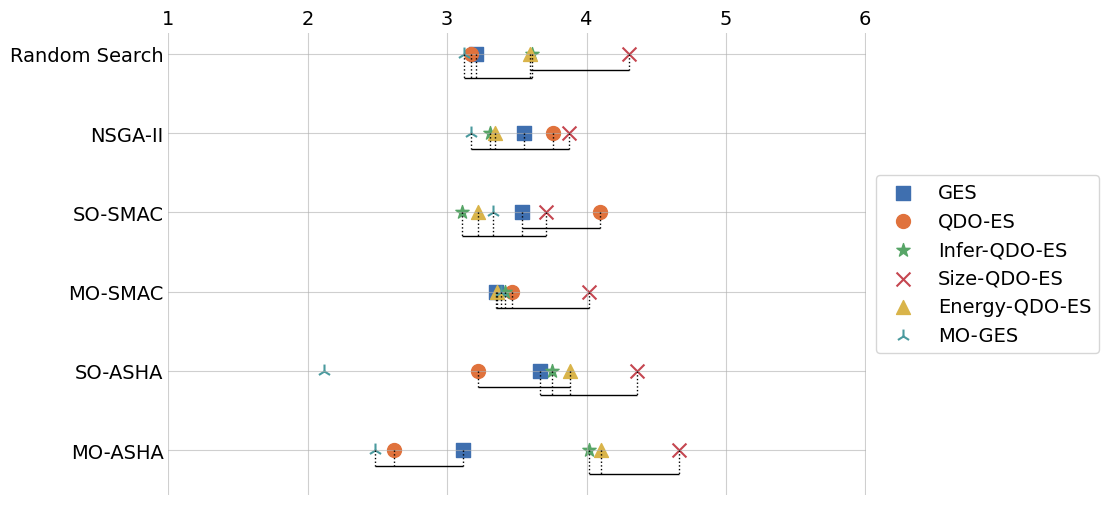

In [49]:
plot_cds(task_ids, results_arr, frequency="no-boost", metric="Hypervolume incl. BMP", mode="max")

               meanrank    median       mad  ci_lower  ci_upper effect_size   magnitude effect_size_above magnitude_above
Size-QDO-ES    4.197115 -1.242273  0.170143 -1.394492 -1.122546         0.0  negligible               0.0      negligible
Infer-QDO-ES   3.865385 -1.257682  0.168696 -1.365364 -1.130074    0.061347  negligible          0.061347      negligible
QDO-ES         3.788462 -1.248886  0.175074 -1.370931 -1.117863    0.025841  negligible          -0.03451      negligible
Energy-QDO-ES  3.725962 -1.233365  0.149845  -1.35043   -1.1296   -0.037475  negligible         -0.064245      negligible
GES            2.836538 -1.193237  0.181769 -1.360006 -1.091333   -0.187866  negligible         -0.162489      negligible
MO-GES         2.586538 -1.158196  0.118034 -1.248395 -1.070675   -0.387289       small         -0.154222      negligible
               meanrank    median       mad  ci_lower  ci_upper effect_size   magnitude effect_size_above magnitude_above
Size-QDO-ES    4.326923 

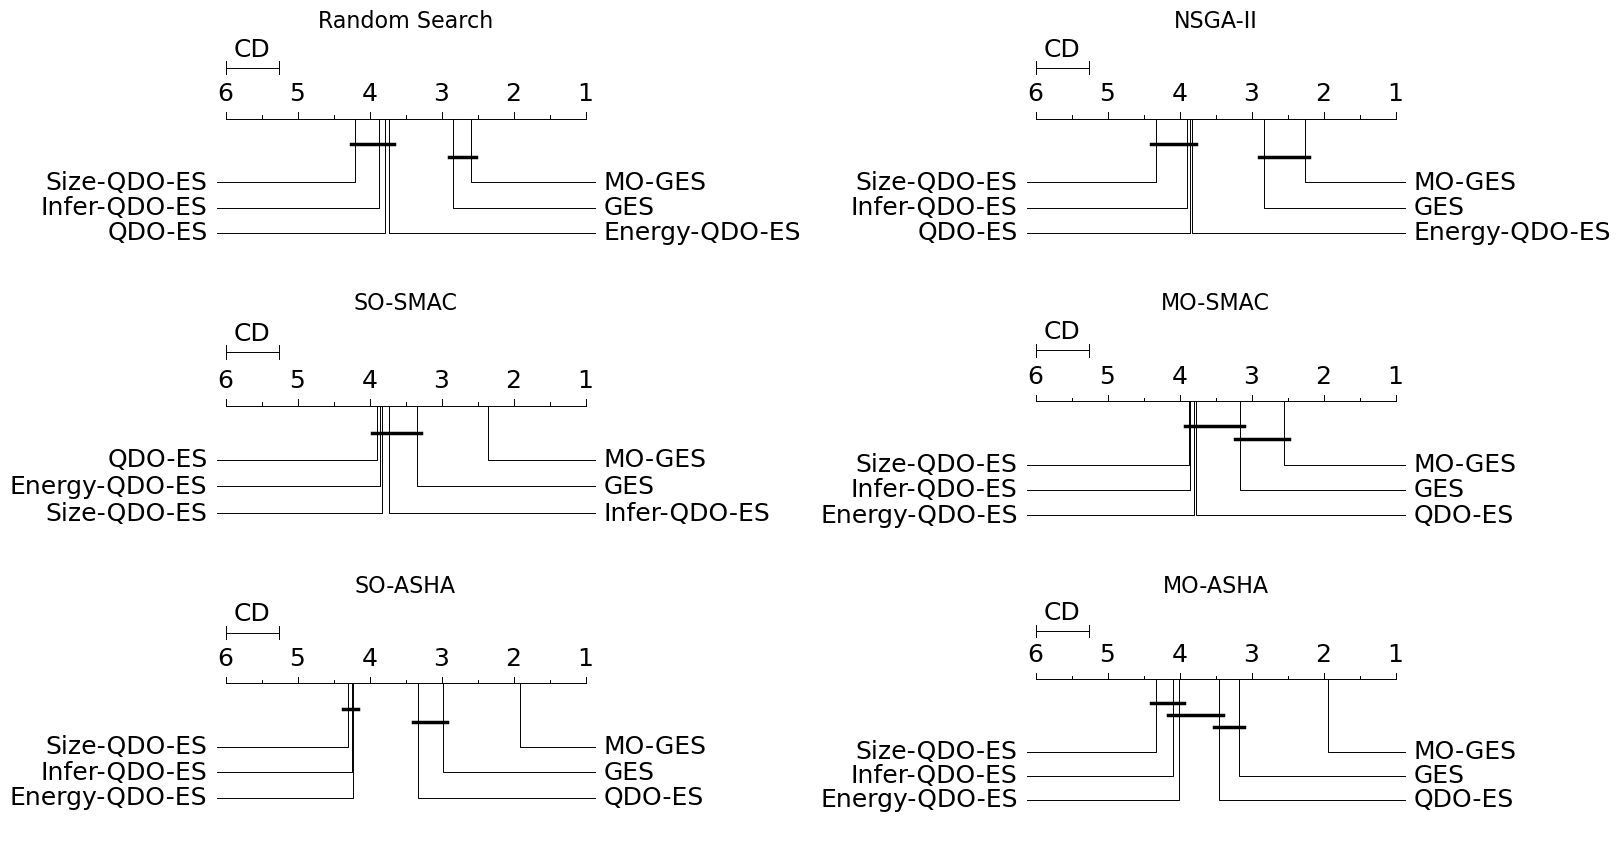

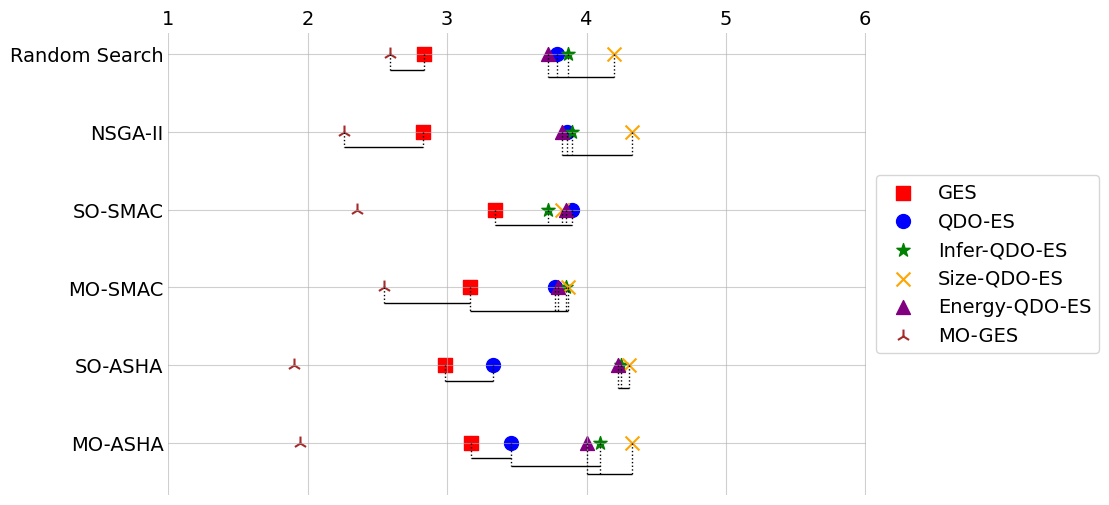

In [ ]:
plot_cds(task_ids, results_arr, frequency="no-boost", metric="Spread incl. BMP", mode="min")

# Comparison Predictive Performance

               meanrank    median       mad  ci_lower  ci_upper effect_size   magnitude effect_size_above magnitude_above
Size-QDO-ES    4.341346 -0.066039  0.043456 -0.116667 -0.038436         0.0  negligible               0.0      negligible
Energy-QDO-ES  3.860577 -0.060668  0.041198 -0.106377 -0.037018   -0.085552  negligible         -0.085552      negligible
Infer-QDO-ES   3.783654 -0.062095  0.043312  -0.11376 -0.037666   -0.061309  negligible          0.022775      negligible
MO-GES         3.206731 -0.054742  0.037633 -0.098195 -0.034326   -0.187439  negligible         -0.122236      negligible
GES            3.197115 -0.064823   0.04569 -0.102952 -0.029415   -0.018389  negligible          0.162445      negligible
QDO-ES         2.610577 -0.048343  0.033827 -0.090081 -0.026844   -0.306515       small         -0.276524           small
               meanrank    median       mad  ci_lower  ci_upper effect_size   magnitude effect_size_above magnitude_above
Size-QDO-ES    3.913462 

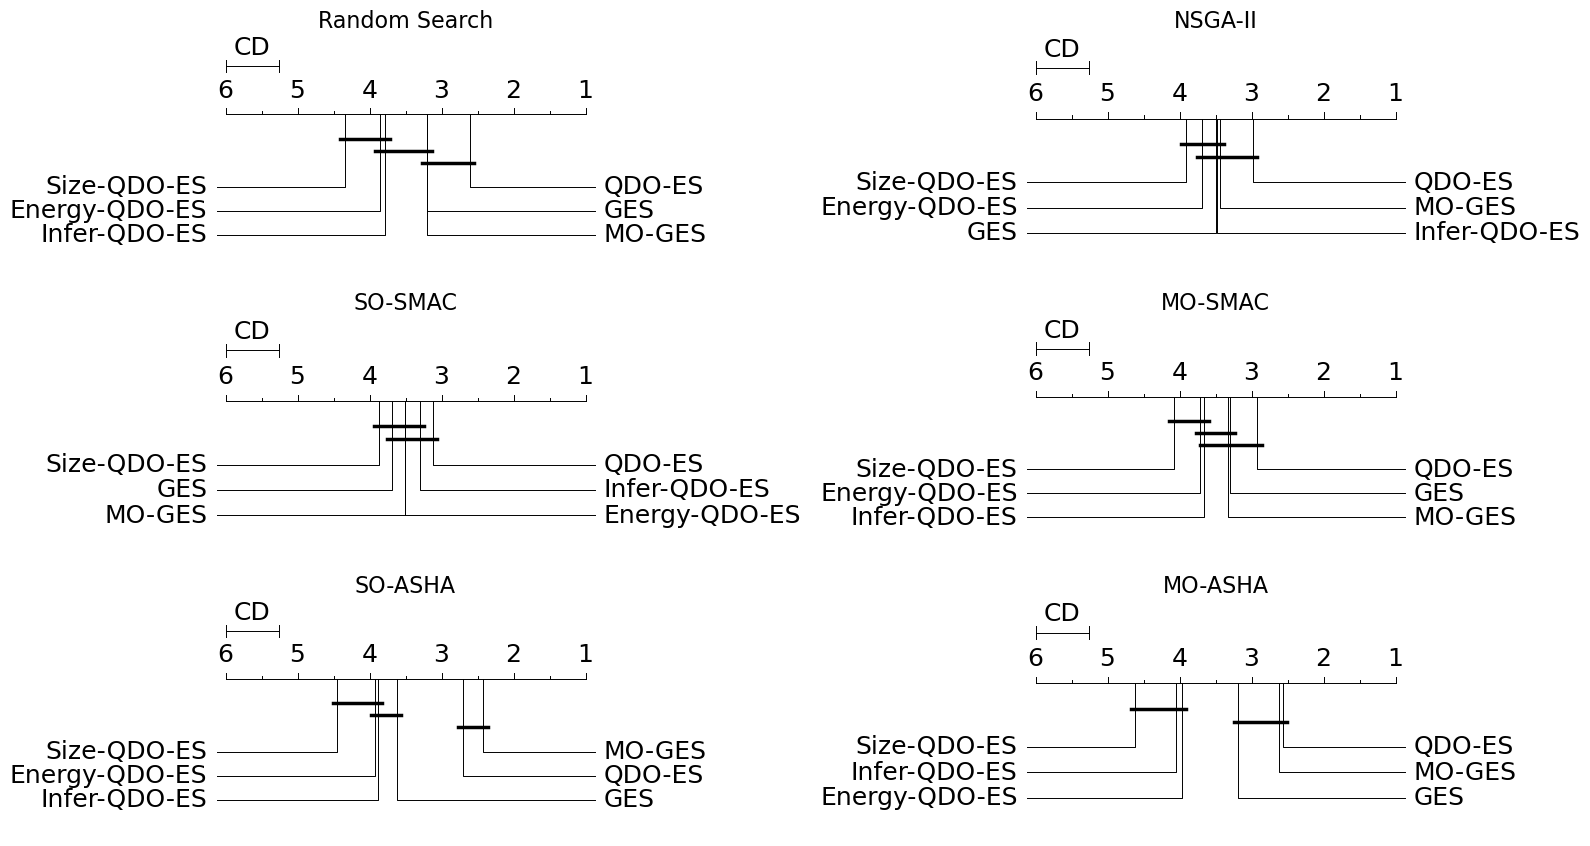

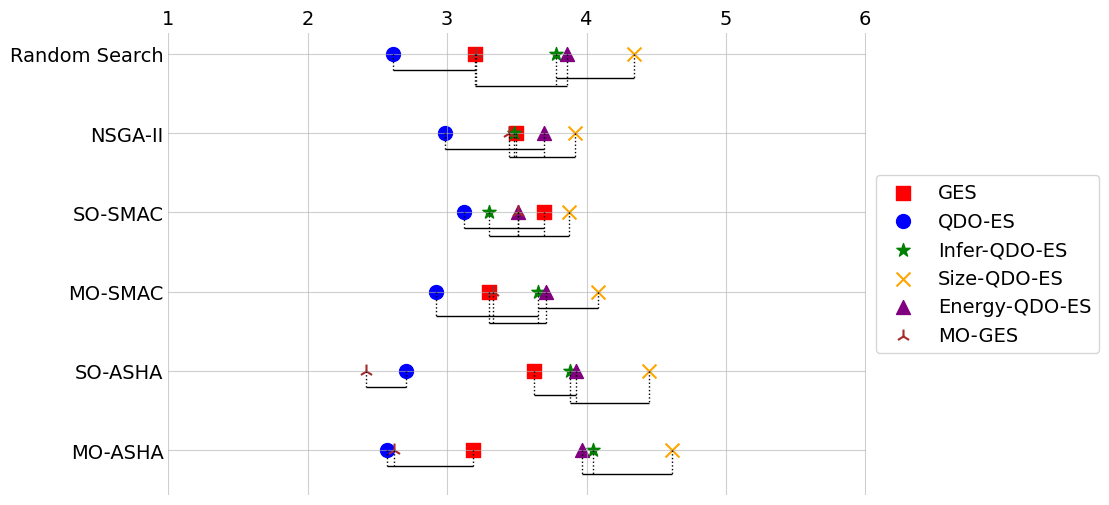

In [28]:
plot_cds(task_ids, results_arr, frequency="no-boost", metric="Predictive Metric Ensembling", mode="min")

# Takeaways

- MO-GES performs statsitically significantly best w.r.t HV and best (without stat. sig.) w.r.t HV incl. BMP
- MO-GES performs statistically significantly better than INFER/ENERGY/SIZE-QDO-ES w.r.t. Spread across all BMGs 
- MO-GES is not really worse than GES w.r.t. predictive performance and in low-data regimes (ASHA) actually outperforms QDO-ES (while not statistically signficant)

# Comparison Runtime Ensembling!

In [29]:
def plot_runtimes(task_groups, frequency, runtimes, bmg_method, pruning_method):
    """
    Plots relative runtimes for different ensembling methods as grouped boxplots.

    Args:
        task_groups (dict): Mapping from group name -> list of task_ids
        frequency: frequency filter
        runtimes: numpy array of runtimes (shape: tasks x bmg x ensembling x ...)
        bmg_method: BMG method to select
        pruning_method: pruning method to select
    """
    if isinstance(task_groups, list):
        task_groups = {"": task_groups}

    # Filter by frequency, BMG method, and pruning
    runtimes_filtered = np.take(runtimes, freq_to_idx[frequency], axis=0)
    i_bmg = bmg_to_idx[bmg_method]
    runtimes_filtered = np.take(runtimes_filtered, i_bmg, axis=1)
    runtimes_filtered = np.take(runtimes_filtered, prune_to_idx[pruning_method], axis=-1)

    fig, ax = plt.subplots(figsize=(8, 6))

    # Colors for task groups
    palette = ["blue", "orange", "green", "red", "purple", "brown"]
    group_colors = {name: palette[i % len(palette)] for i, name in enumerate(task_groups.keys())}

    legend_handles = []

    positions = []
    cluster_centers = []
    pos = 1

    # Iterate through ensembling methods
    for method in ENSEMBLING_METHODS:
        if method == "ges":
            continue

        cluster_start = pos

        for group_name, task_ids in task_groups.items():
            task_indices = [task_id_to_idx[tid] for tid in task_ids]
            runtimes_group = np.take(runtimes_filtered, task_indices, axis=0)
            runtimes_mean = np.mean(runtimes_group, axis=1)

            # relative to GES
            ges_runtime = np.mean(np.take(runtimes_group, es_to_idx["ges"], axis=1), axis=1, keepdims=True)
            rel_runtime = runtimes_mean[:, es_to_idx[method]] / ges_runtime.flatten()

            bp = ax.boxplot(
                rel_runtime,
                positions=[pos],
                widths=0.6,
                showfliers=True,
                patch_artist=True
            )
            for patch in bp["boxes"]:
                patch.set_facecolor(group_colors[group_name])
            for median in bp["medians"]:
                median.set_color("black")

            positions.append(pos)
            pos += 1

            # legend handle
            if group_name not in [h.get_label() for h in legend_handles]:
                legend_handles.append(
                    plt.Line2D([0], [0], color=group_colors[group_name], lw=8, label=group_name)
                )

        cluster_end = pos - 1
        cluster_centers.append((cluster_start + cluster_end) / 2)

        # gap between clusters
        pos += 1

    # ----- X-Axis: ensembling method labels -----
    method_labels = [ENSEMBLING_METHODS_DICT[m] for m in ENSEMBLING_METHODS if m != "ges"]
    ax.set_xticks(cluster_centers)
    ax.set_xticklabels(method_labels, rotation=0, fontsize=9)

    ax.set_title(f"Relative Runtimes (BMG: {BMG_METHODS_DICT[bmg_method]}, "
                 f"Pruning: {PRUNING_METHODS_DICT[pruning_method]})")
    ax.set_ylabel("Relative to GES Runtime")
    ax.grid(axis="y")

    if len(legend_handles) > 1:
        ax.legend(handles=legend_handles, title="Task Groups", title_fontsize=12)
    plt.tight_layout()
    plt.show()



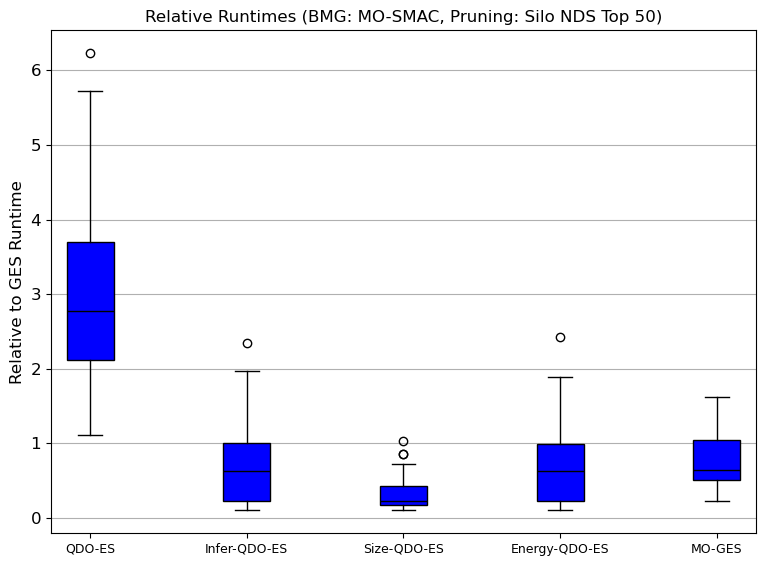

In [30]:
runtimes_ensembling = np.take(results_arr, RESULTS_ORDER.index("Runtime Ensembling"), axis=-1)
plot_runtimes(task_ids, "no-boost", runtimes_ensembling, bmg_method="mo-smac", pruning_method="nd_50_silo")

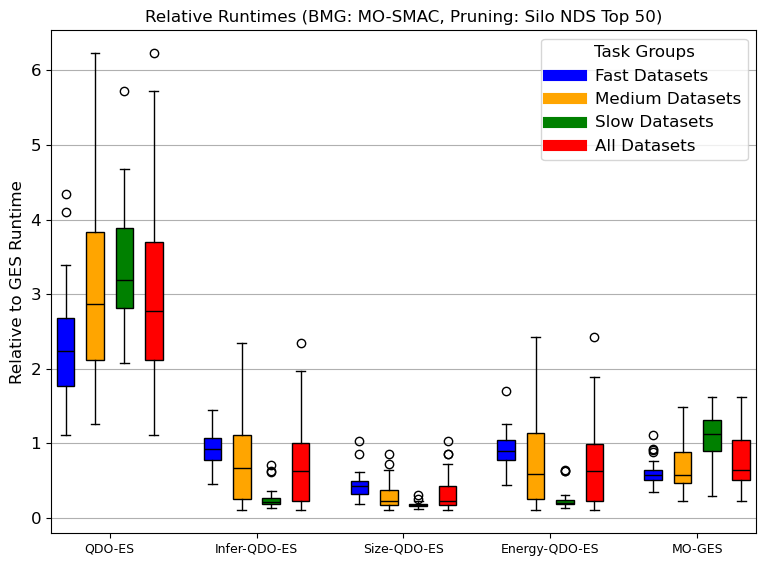

In [31]:
slow_ids = get_group_task_ids("slow")
medium_ids = get_group_task_ids("medium")
fast_ids = get_group_task_ids("fast")

data_dict = {
    "Fast Datasets": fast_ids,
    "Medium Datasets": medium_ids,
    "Slow Datasets": slow_ids,
    "All Datasets": task_ids
}

plot_runtimes(data_dict, "no-boost", runtimes_ensembling, bmg_method="mo-smac", pruning_method="nd_50_silo")

# Heatmaps

In [32]:
data = pd.read_csv("./data/base_ensemble_pools.csv", index_col=0)
#data_meta = pd.read_csv("./data/base_ensemble_pools_meta.csv")
grouped = data.groupby("pool_index")

In [33]:
ensembling_pools = {}

for g_index, g_data in tqdm.tqdm(grouped, total=grouped.ngroups):
    task_id = g_data["task_id"].iloc[0]
    seed = g_data["seed"].iloc[0]
    bmg_method = g_data["bmg_method"].iloc[0]
    frequency = g_data["frequency"].iloc[0]
    es_method = g_data["es_method"].iloc[0]
    filter = g_data["filter"].iloc[0]

    cols = ["RMSE", "Log Loss", "1 - ROC AUC", "inference_time", "energy_consumption"]
    cols = [col for col in cols if (~g_data[col].isna()).sum() > 0]

    min_val, max_val = min_max_values[task_id]
    min_arr, max_arr = np.array([min_val[col] for col in cols]), np.array([max_val[col] for col in cols])

    data_norm = g_data[cols].values
    data_norm = (data_norm - min_arr) / (max_arr - min_arr)

    ensembling_pools[(task_id, seed, bmg_method, filter, es_method, frequency)] = data_norm

100%|██████████| 177672/177672 [01:57<00:00, 1509.74it/s]


In [ ]:
def plot_solutions_heatmap(
    bmps,
    ensembling_pools,
    task_ids,
    bmg_method="mo-smac",
    pruning_method="nd_50_silo",
    ensembling_method="ges",
    frequency="no-boost",
    second_metric="energy_consumption",
    ranges=[[0,1],[0,.1]]
):
    assert second_metric in ["inference_time", "energy_consumption"], "Invalid second metric"
    metric_index = ["inference_time", "energy_consumption"].index(second_metric)

    data_agg = []
    for task_id in task_ids:
        for seed in range(1,6):
            key_bmp = (task_id, seed, bmg_method, frequency)
            key_ens = (task_id, seed, bmg_method, pruning_method, ensembling_method, frequency)
            if key_bmp in bmps and key_ens in ensembling_pools:
                pool_bmp = bmps[key_bmp]
                pool_ens = ensembling_pools[key_ens]
                pool_both = np.vstack([pool_bmp, pool_ens])
                is_pareto = get_pareto_front(pool_both)
                for i in range(pool_both.shape[0]):
                    if is_pareto[i]:
                        data_agg.append({"Method": "Base Model Pool" if i < pool_bmp.shape[0] else ENSEMBLING_METHODS_DICT[ensembling_method],
                                         "Predictive Performance": pool_both[i,0],
                                         f"{'Inference Time' if second_metric == 'inference_time' else 'Energy Consumption'}": pool_both[i, metric_index+1]})
    data_df = pd.DataFrame(data_agg)

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.scatterplot(
        data=data_df,
        x="Predictive Performance",
        y=f"{'Inference Time' if second_metric == 'inference_time' else 'Energy Consumption'}",
        hue="Method",
        alpha=0.7,
        s=60,
        ax=ax
    )

    # sns.kdeplot(
    #     data_df,
    #     x="Predictive Performance",
    #     y=f"{'Inference Time' if second_metric == 'inference_time' else 'Energy Consumption'}",
    #     hue="Method",
    #     fill=True, levels=20, thresh=0.05, 
    #     alpha=0.5,
    # )
    plt.xlabel("Predictive Performance (normalized)")
    plt.ylabel(f"{'Inference Time' if second_metric == 'inference_time' else 'Energy Consumption'} (normalized)")
    plt.ylim(*ranges[1])
    plt.xlim(*ranges[0])
    plt.show()

[2073, 3945, 7593, 10090, 146818, 146820, 167120, 167210, 168350, 168757, 168784, 168868, 168909, 168910, 168911, 189354, 189355, 189356, 189922, 190137, 190146, 190392, 190410, 190411, 190412, 211979, 211986, 233211, 233212, 233213, 233214, 233215, 317614, 359929, 359930, 359931, 359932, 359933, 359934, 359935, 359936, 359937, 359938, 359939, 359940, 359941, 359942, 359943, 359944, 359945, 359946, 359948, 359949, 359950, 359951, 359952, 359953, 359954, 359955, 359956, 359957, 359958, 359959, 359960, 359961, 359962, 359963, 359964, 359965, 359966, 359967, 359968, 359969, 359970, 359971, 359972, 359973, 359974, 359975, 359976, 359977, 359979, 359980, 359981, 359982, 359983, 359984, 359985, 359986, 359987, 359988, 359989, 359990, 359991, 359992, 359993, 359994, 360112, 360113, 360114, 360932, 360933, 360945, 360975]


ValueError: Could not interpret value `Predictive Performance` for `x`. An entry with this name does not appear in `data`.

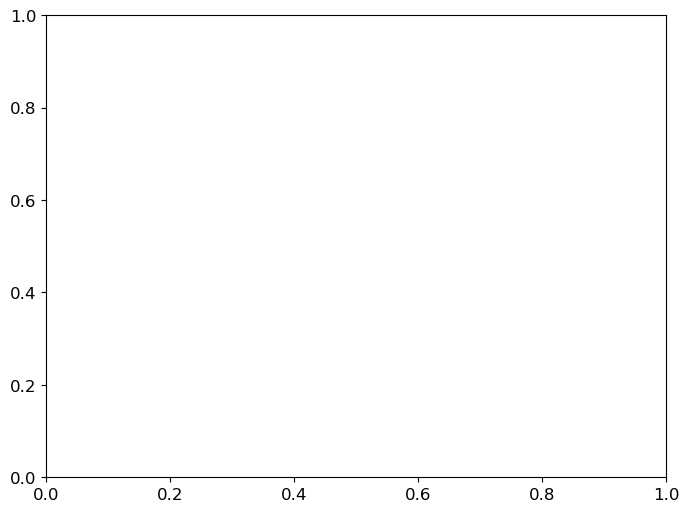

In [65]:
print(task_ids)

plot_solutions_heatmap(
    bmps,
    ensembling_pools,
    [360975],
    bmg_method="mo-smac",
    pruning_method="nd_50_silo",
    ensembling_method="mo-ges",
    frequency="no-boost",
    second_metric="inference_time",
    ranges=[[0,1],[0,.25]]
)    

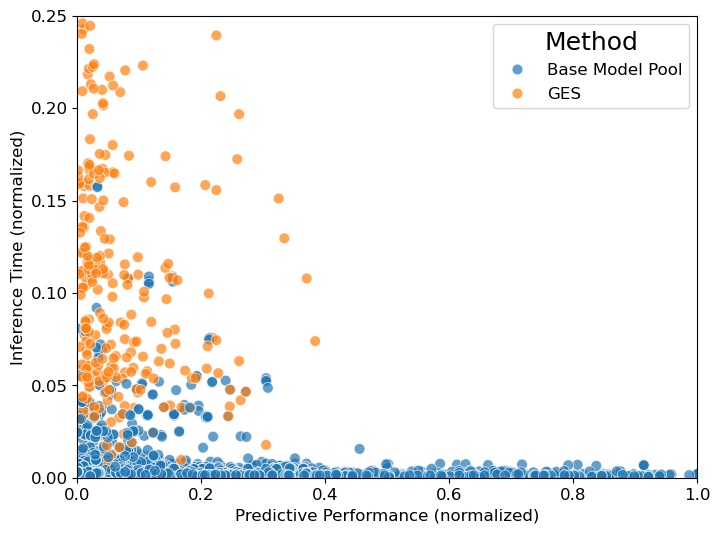

In [54]:
plot_solutions_heatmap(
    bmps,
    ensembling_pools,
    task_ids,
    bmg_method="mo-smac",
    pruning_method="nd_50_silo",
    ensembling_method="ges",
    frequency="no-boost",
    second_metric="inference_time",
    ranges=[[0,1],[0,.25]]
)    

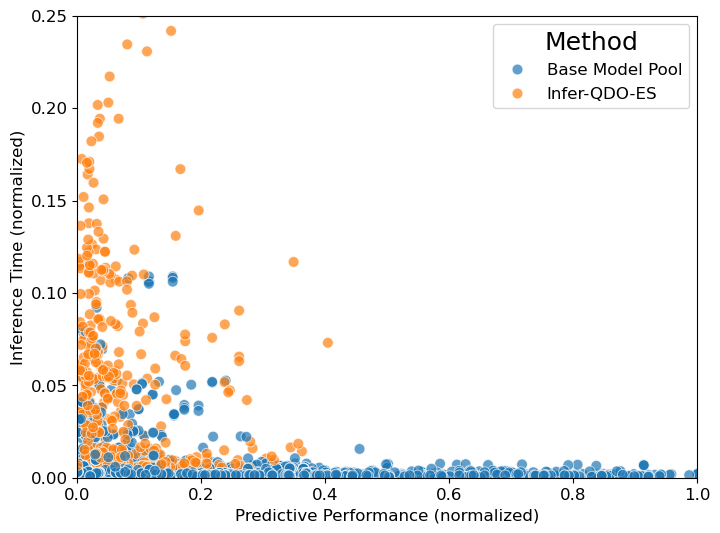

In [55]:
plot_solutions_heatmap(
    bmps,
    ensembling_pools,
    task_ids,
    bmg_method="mo-smac",
    pruning_method="nd_50_silo",
    ensembling_method="infer-qdo-es",
    frequency="no-boost",
    second_metric="inference_time",
    ranges=[[0,1],[0,.25]]
)    

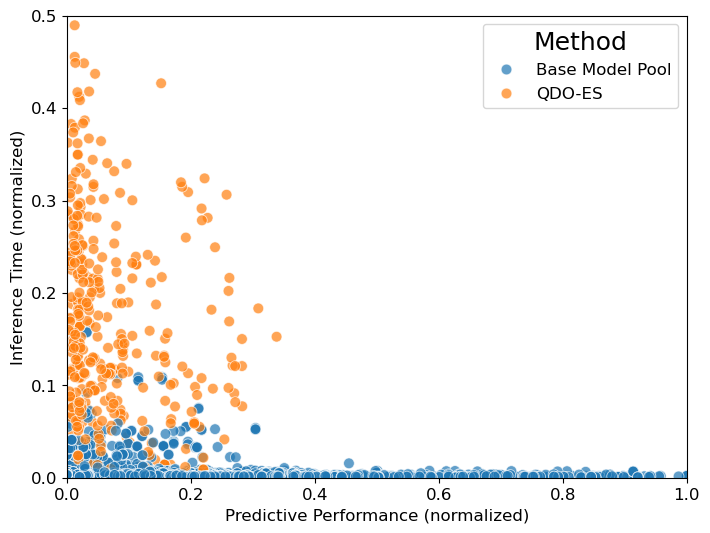

In [56]:
plot_solutions_heatmap(
    bmps,
    ensembling_pools,
    task_ids,
    bmg_method="mo-smac",
    pruning_method="nd_50_silo",
    ensembling_method="qdo-es",
    frequency="no-boost",
    second_metric="inference_time",
    ranges=[[0,1],[0,.5]]
)    